# Project Setup

Import Required Libraries

In [1]:
import sys
print(sys.executable)

c:\Users\musta\AppData\Local\Python\pythoncore-3.11-64\python.exe


In [2]:
%pip install numpy pandas scikit-learn xgboost matplotlib seaborn shap yellowbrick polars

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# Import libraries

# For Colab
#import gdown
#from google.colab import drive

# For data analysis
import numpy as np
import pandas as pd
import polars as pl
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer
from yellowbrick.cluster.elbow import kelbow_visualizer
%matplotlib inline

# For garbage collection
import gc

# Regression
from xgboost import XGBRegressor
from sklearn.linear_model import ElasticNet, ElasticNetCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, train_test_split, StratifiedKFold
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score
from sklearn.model_selection import KFold

# Model evaluation tools
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import shap

c:\Users\musta\AppData\Local\Python\pythoncore-3.11-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Load raw data for demographics and household spending

In [4]:
# Mount Google Drive
#drive.mount('/content/drive/')

In [5]:
# Confirm files are in the expected path
!ls "C:\Users\musta\Documents\Projects\household data dashboard\Data"

'ls' is not recognized as an internal or external command,
operable program or batch file.


In [6]:
# Original file locations for A.B.
#demo_data = pl.read_csv("/content/drive/My Drive/DS3000/coursework_data/DemoStats.csv", null_values = "NA").sample(fraction = 0.1, seed = 2025)
# household_data = pl.read_csv("/content/drive/My Drive/DS3000/coursework_data/HouseholdSpend.csv", null_values = "NA").sample(fraction = 0.1, seed = 2025)

# For local work
demo_data = pl.read_csv(r"C:\Users\musta\Documents\Projects\household data dashboard\Data\DemoStats.csv", null_values = "NA").sample(fraction = 0.1, seed = 2025)
household_data = pl.read_csv(r"C:\Users\musta\Documents\Projects\household data dashboard\Data\HouseholdSpend.csv", null_values = "NA").sample(fraction = 0.1, seed = 2025)

Preview Initial Dataset Dimensions

In [7]:
print(f"demo_data shape: {demo_data.shape}")
print(f"household_data shape: {household_data.shape}")

demo_data shape: (86897, 736)
household_data shape: (86897, 246)


# Data Cleaning & Preparation

Drop zero-only rows (Household)

In [8]:
%pip install pyarrow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
###
#
# Cleaning out all zero only rows
# DemoStats data has no rows that have 0s
#
###

# Convert Househould Data into pandas since we are checking by rows
household_data = household_data.to_pandas()

# Select only numeric columns
household_numeric_data = household_data.select_dtypes(include='number')

# Create a boolean mask for rows where all numeric columns equal 0
house_mask = (household_numeric_data == 0).all(axis=1)

# Count the rows that are only zeros
house_zero_row_count = house_mask.sum()
print("Household Rows with only zeros:", house_zero_row_count)

# Remove the rows: use mask.values (a 1D numpy array) for indexing
household_data = household_data.loc[house_mask.values == False]

# Optional: reset the index
household_data = household_data.reset_index(drop=True)

# Convert Household Data back to polars
household_data = pl.from_pandas(household_data)

# Deleting unnecessary variables
# del [household_numeric_data, house_mask, house_zero_row_count]
del household_numeric_data, house_mask, house_zero_row_count

# Trigger Garbage Collection
gc.collect()

Household Rows with only zeros: 9355


20

Make sure 0-filled rows were removed (Household)

In [10]:
# Convert again to pandas for checking
household_data_check = household_data.to_pandas()

# Select numeric columns
numeric_check = household_data_check.select_dtypes(include='number')

# Check if any rows are still entirely zero
remaining_zeros = (numeric_check == 0).all(axis=1).sum()
print("Remaining zero-only rows after cleanup:", remaining_zeros)

# Cleanup variables
del household_data_check, numeric_check, remaining_zeros
gc.collect()

Remaining zero-only rows after cleanup: 0


0

Drop zero-only rows (Demographics)

In [11]:
###
#
# Cleaning out all zero only rows (Demographics dataset)
#
###

# Convert Househould Data into pandas since we are checking by rows
demo_data = demo_data.to_pandas()

# Select only numeric columns
demo_numeric_data = demo_data.select_dtypes(include='number')

# Create a boolean mask for rows where all numeric columns equal 0
demo_mask = (demo_numeric_data == 0).all(axis=1)

# Count the rows that are only zeros
demo_zero_row_count = demo_mask.sum()
print("Demographic Rows with only zeros:", demo_zero_row_count)

# Remove the rows: use mask.values (a 1D numpy array) for indexing
demo_data = demo_data.loc[demo_mask.values == False]

# Optional: reset the index
demo_data = demo_data.reset_index(drop=True)

# Convert Household Data back to polars
demo_data = pl.from_pandas(demo_data)

# Deleting unnecessary variables
# del [household_numeric_data, house_mask, house_zero_row_count]
del demo_numeric_data, demo_mask, demo_zero_row_count

# Trigger Garbage Collection
gc.collect()

Demographic Rows with only zeros: 0


0

In [12]:
# Convert again to pandas for checking
demo_data_check = demo_data.to_pandas()

# Select numeric columns
numeric_check = demo_data_check.select_dtypes(include='number')

# Check if any rows are still entirely zero
remaining_zeros = (numeric_check == 0).all(axis=1).sum()
print("Remaining zero-only rows after cleanup:", remaining_zeros)

# Cleanup variables
del demo_data_check, numeric_check, remaining_zeros
gc.collect()

Remaining zero-only rows after cleanup: 0


0

Checking dataset dimensions again

In [13]:
household_data.shape

(77542, 246)

In [14]:
# Note that demographics data has more columns than household data
# # I don't think an observation is useful if demographics data was present but household data was 0-filled
demo_data.shape

(86897, 736)

Look at the first few rows of the household data

In [15]:
household_data.head()

CODE,GEO,HSBASHHD,HSHNIAGG,HSAGDISPIN,HSAGDISCIN,HSTT001,HSTE001,HSTX001,HSTC001,HSSH001S,HSFD001S,HSHO001S,HSHC001S,HSHF001S,HSTR001S,HSRE001S,HSPC001S,HSCL001S,HSED002S,HSRO001S,HSTA001S,HSGC001S,HSME001S,HSEP001S,HSMG001S,HSTE001ZBS,HSWH002S,HSWH028S,HSWH040S,HSWH041S,HSWH042S,HSSH001,HSSH002,HSSH003,HSSH004,HSSH053,…,HSTR002,HSTR003,HSTR004,HSTR005,HSTR006,HSTR007,HSTR008,HSTR009,HSTR058,HSTR010,HSTR011,HSTR012,HSTR014M,HSTR015,HSTR020,HSTR030,HSTR031,HSTR032,HSTR033,HSTR034,HSTR035,HSTR036,HSTR037,HSTR038,HSTR039,HSTR040,HSTR041,HSTR050,HSTR051,HSTR052,HSTR053,HSTR054,HSTR055,HSTR056,HSTR056A,HSTR056B,HSTR057
str,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""T3B3V1""","""FSALDU""",24,3.7050e6,2.8432e6,2.1837e6,3.8920e6,3.4002e6,700349.842904,2.3674e6,543124.671557,437309.314727,175184.303667,167510.054981,110460.27669,360060.836664,137547.209588,58457.084832,95346.478644,38449.666971,5186.937319,121253.199077,61694.856627,55786.305321,168656.262874,163871.628076,491747.261741,105795.494492,4761.527106,349501.618471,13353.987306,18334.634366,543124.671557,378616.699983,66402.744871,65985.918524,65286.80801,…,282190.021243,123968.420201,119458.202558,13343.657118,7292.491487,98822.053952,208.805056,57.262324,151.542732,4301.412587,3528.680405,1369.234408,2159.445998,772.732182,4773.094537,153448.506505,1590.451769,14762.436645,12634.368139,36903.474042,107.912235,75130.164336,1388.570046,10145.658883,785.47041,236.808371,548.662039,77870.815422,8340.079317,3190.676194,211.265535,62704.272253,59.820565,1465.239904,1344.029846,121.210058,1899.461654
"""S7H4W6""","""FSALDU""",23,2.5218e6,2.0026e6,1.3863e6,2.9536e6,2.4997e6,357731.524042,1.9349e6,463076.731484,359505.579191,131366.057819,134141.35162,85405.437664,306302.50736,117802.978392,51807.973996,67964.469829,21469.681027,4352.994455,97576.617541,52997.273966,41111.092218,156830.08112,50277.631786,453925.20123,87714.97769,3585.300315,329179.273898,19705.28474,13740.364589,463076.731484,366661.917558,43068.052211,42702.059239,42466.94353,…,288438.257277,99061.955269,96792.659624,5510.568944,4018.591418,87263.499261,555.849938,88.354855,467.495082,1713.445708,1451.272392,567.453735,883.818657,262.173316,1325.951994,188050.350014,12910.159738,13316.990639,21470.394892,36573.511533,170.723056,95844.070267,1855.917407,5340.763883,567.818598,386.519277,181.299321,17864.250083,2357.416104,1391.135719,4.248428,11979.675631,46.871145,929.258912,913.655061,15.603851,1155.644144
"""T1Y5N8""","""FSALDU""",29,3.2017e6,2.6645e6,1.8612e6,3.2964e6,2.9832e6,375100.639075,2.3869e6,609015.69103,441677.776748,174996.686166,153777.018407,96608.5956,377716.927379,139917.526782,67600.744989,98968.155745,54163.290154,3709.929479,72355.899129,56303.182249,40078.732782,169454.559275,51709.030705,313212.403354,74420.406283,1998.988927,197906.928303,22635.393417,16250.686423,609015.69103,493107.268286,65919.741149,65533.576926,64869.989105,…,299466.909522,138035.399178,134370.935173,10244.021361,11946.875274,112180.038538,291.010335,119.033706,171.97663,3373.45367,3167.524641,1404.757944,1762.766697,205.929029,2214.178731,159217.331613,2114.295254,16786.106411,12897.28072,26247.759353,69.738817,87065.480758,1858.381402,9981.813896,2196.475002,322.416785,1874.058217,78250.017857,12075.325126,2462.906027,118.980225,61453.777707,77.068795,804.771985,701.039891,103.732094,1257.187992
"""S7H3T2""","""FSALDU""",10,770705.467683,636706.978384,425652.738936,710094.867303,760377.602442,81694.726719,608756.996511,162513.141543,104906.430849,49175.323645,49400.491199,20820.602654,83024.92618,33394.053022,13936.137266,24060.658103,12371.904316,1257.294488,28328.983737,9513.916772,16053.132738,51129.740435,18796.138777,-50282.735139,15111.93633,555.308637,-71286.549

Look at the first few rows of the demographics data

In [16]:
demo_data.head()

CODE,GEO,ECYASQKM,ECYALSQKM,ECYBASPOP,ECYBASHHD,ECYBASHPOP,ECYBAS12P,ECYBAS15P,ECYBAS18P,ECYBAS19P,ECYBAS12HP,ECYBAS15HP,ECYBAS18HP,ECYBAS19HP,ECYBASTNGH,ECYBASADUH,ECYBASCF,ECYBASCFH,ECYBASKID,ECYBASLF,ECYPTAPOP,ECYPTA_0_4,ECYPTA_5_9,ECYPTA1014,ECYPTA1519,ECYPTA2024,ECYPTA2529,ECYPTA3034,ECYPTA3539,ECYPTA4044,ECYPTA4549,ECYPTA5054,ECYPTA5559,ECYPTA6064,ECYPTA6569,ECYPTA7074,…,ECYRIMINDI,ECYRIMNEPA,ECYRIMPAKI,ECYRIMSRI,ECYRIMSASO,ECYRIMOCE,ECYRIMAUSS,ECYRIMOCEO,ECYPIMHPOP,ECYPIMNI,ECYPIMIM,ECYPIMP01,ECYPIM0110,ECYPIM1115,ECYPIM1621,ECYPIM22CY,ECYPIMNPER,ECYAIMHPOP,ECYAIMNI,ECYAIMIM,ECYAIM_0_5,ECYAIM_514,ECYAIM1524,ECYAIM2544,ECYAIM45P,ECYAIMNPER,ECYGENHPOP,ECYGEN1GEN,ECYGEN2GEN,ECYGEN3GEN,ECYTCAHPOP,ECYTCACIT,ECYTCA_U18,ECYTCA_18P,ECYNCANCIT,ECYNCA_U18,ECYNCA_18P
str,str,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,…,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64
"""T3B3V1""","""FSALDU""",0,0,61,24,61,54,52,50,50,55,52,51,50,4,31,21,20,15,32,61,3,3,3,3,2,3,2,4,4,3,4,5,6,5,4,…,0,0,0,0,0,0,0,0,61,47,14,5,3,4,1,1,0,61,47,14,4,4,0,6,0,0,61,14,16,31,61,61,10,51,0,0,0
"""S7H4W6""","""FSALDU""",0,0,53,23,53,47,46,43,42,46,46,43,42,3,24,19,19,13,31,53,2,3,2,5,2,3,3,4,2,3,3,2,4,5,4,…,5,0,0,0,0,0,0,0,53,37,15,3,0,0,4,8,1,53,37,15,1,0,7,6,1,1,53,16,4,33,53,43,8,35,10,2,8
"""T1Y5N8""","""FSALDU""",0,0,90,29,90,76,72,69,68,78,72,69,68,9,45,23,22,34,36,90,5,6,7,5,7,5,5,6,7,6,5,5,6,6,4,…,4,0,0,0,0,0,0,0,90,47,42,9,4,11,7,11,1,90,47,42,5,8,6,23,0,1,90,43,20,27,90,76,18,58,14,3,11
"""V6B5E8""","""FSALDU""",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"""S7H3T2""","""FSALDU""",0,0,23,10,23,20,19,18,18,21,19,18,18,3,13,5,2,6,13,23,0,2,2,1,1,3,1,2,2,1,2,1,1,1,1,…,0,0,0,0,0,0,0,0,23,17,6,2,0,0,3,1,0,23,17,6,0,0,0,6,0,0,23,6,0,17,23,22,5,17,1,0,1


Summarizing variable types for the household and demogaphics datasets

In [17]:
# Summarizing the variable data types for the household dataset

# Create a dataframe with variable names and data types
column_info_df = pl.DataFrame(
    {
        "column": list(household_data.schema.keys()), # Get column names
        "data_type": [str(dtype) for dtype in household_data.schema.values()], # Get and convert data types to string
    }
)

# Get value counts for data types
column_info_df.group_by("data_type").agg(pl.len().alias("count")).sort("count", descending = True)

data_type,count
str,u32
"""Float64""",243
"""String""",2
"""Int64""",1


In [18]:
# Summarizing the variable data types for the demographic dataset

# Create a dataframe with variable names and data types
column_info_df = pl.DataFrame(
    {
        "column": list(demo_data.schema.keys()), # Get column names
        "data_type": [str(dtype) for dtype in demo_data.schema.values()], # Get and convert data types to string
    }
)

# Get value counts for data types
column_info_df.group_by("data_type").agg(pl.len().alias("count")).sort("count", descending = True)

data_type,count
str,u32
"""Int64""",706
"""Float64""",28
"""String""",2


Inspecting the string columns

In [19]:
# Checking out the string variables for the household dataset
# Should drop "GEO" because it's not unique to each observation
household_data.select(pl.col(pl.String)).head(5)

CODE,GEO
str,str
"""T3B3V1""","""FSALDU"""
"""S7H4W6""","""FSALDU"""
"""T1Y5N8""","""FSALDU"""
"""S7H3T2""","""FSALDU"""
"""M1L3A8""","""FSALDU"""


In [20]:
# Checking out the string variables for the demographics dataset
# Should drop "GEO" because it's not unique to each observation
demo_data.select(pl.col(pl.String)).head(5)

CODE,GEO
str,str
"""T3B3V1""","""FSALDU"""
"""S7H4W6""","""FSALDU"""
"""T1Y5N8""","""FSALDU"""
"""V6B5E8""","""FSALDU"""
"""S7H3T2""","""FSALDU"""


Drop Uninformative String Columns

In [21]:
# Drop the GEO columns from both datasets because they're not unique to each observation
household_data = household_data.drop("GEO")
demo_data = demo_data.drop("GEO")

Remove Zero-Filled Columns (Household)

In [22]:
# Finding and removing 0-filled columns in the household dataset

# List to store the names of zero-only columns
zero_cols = []

# Loop over all columns, checking each if only zeros are present
# If so, append the column name to the zero_cols list
for col in household_data.columns:

    # Check if all values in this column are zero
    if (household_data[col] == 0).all():
        zero_cols.append(col)

In [23]:
# No zero-filled columns found in the household dataset
len(zero_cols)

0

Remove Zero-Filled Columns (Demographic)

In [24]:
# Finding and removing 0-filled columns in the demographics dataset

# Create an empty list to hold numeric column names
numeric_cols = []

# Identify numeric columns
for col, dtype in demo_data.schema.items():
    if dtype in (
        pl.Int8, pl.Int16, pl.Int32, pl.Int64,
        pl.UInt8, pl.UInt16, pl.UInt32, pl.UInt64,
        pl.Float32, pl.Float64
    ):
        numeric_cols.append(col)

# Create an empty list for zero-filled columns
zero_cols = []

# Check each numeric column for all-zero values (ignoring nulls by treating them as zero)
for col in numeric_cols:
    col_is_not_zero = demo_data.select(
        (pl.col(col).fill_null(0) != 0).any()
    ).item()

    if not col_is_not_zero:
        zero_cols.append(col)

print("Zero-filled columns:", zero_cols)


Zero-filled columns: ['ECYASQKM', 'ECYALSQKM']


In [25]:
# Two zero-filled columns found in the demographics dataset
len(zero_cols)

2

In [26]:
# Descriptive statistics for the zero-filled columns in the demographics dataset
# There are only 2: ECYASQKM and ECYALSQKM
# These correspond to "Total Area" and "Total Land Area", respectively
# Should probably drop them
demo_data[zero_cols].describe()

statistic,ECYASQKM,ECYALSQKM
str,f64,f64
"""count""",86897.0,86897.0
"""null_count""",0.0,0.0
"""mean""",0.0,0.0
"""std""",0.0,0.0
"""min""",0.0,0.0
"""25%""",0.0,0.0
"""50%""",0.0,0.0
"""75%""",0.0,0.0
"""max""",0.0,0.0


In [27]:
# Drop the zero-filled columns
demo_data = demo_data.drop(zero_cols)

Remove Zero-Filled Columns (Demographic)

In [28]:
# Finding and removing 0-filled columns in the household dataset

# Create an empty list to hold numeric column names
numeric_cols = []

# Identify numeric columns
for col, dtype in household_data.schema.items():
    if dtype in (
        pl.Int8, pl.Int16, pl.Int32, pl.Int64,
        pl.UInt8, pl.UInt16, pl.UInt32, pl.UInt64,
        pl.Float32, pl.Float64
    ):
        numeric_cols.append(col)

# Create an empty list for zero-filled columns
zero_cols = []

# Check each numeric column for all-zero values (ignoring nulls by treating them as zero)
for col in numeric_cols:
    col_is_not_zero = household_data.select(
        (pl.col(col).fill_null(0) != 0).any()
    ).item()

    if not col_is_not_zero:
        zero_cols.append(col)

print("Zero-filled columns:", zero_cols)


Zero-filled columns: []


Handle Negative Values:

For the household dataset

In [29]:
# Find the columns that contain negative values
has_negatives = []

for index, col in enumerate(household_data.columns):
  if (household_data.dtypes[index] == pl.Int64 or household_data.dtypes[index] == pl.Float64):
    minValue = household_data[col].min()
    if (minValue < 0):
      has_negatives.append(col)

print(f"The number of columns that have negative values is: {len(has_negatives)}.\n\nThese columns are:")

for entry in has_negatives:
  print(f"{entry}")

The number of columns that have negative values is: 5.

These columns are:
HSTT001
HSTE001ZBS
HSWH040S
HSWH041S
HSWH042S


In [30]:
# Inspecting the columns that contain negative values, identified above

# Subset the dataframe to only columns with negative values
negatives_df = household_data.select(has_negatives)

# Total number of observations (rows) in the dataset
total_rows = household_data.height

# Count negative values and compute proportion for each column
for col in has_negatives:
    count = negatives_df.filter(negatives_df[col] < 0).height
    proportion = count / total_rows
    print(f"Column '{col}' has {count} negative values ({proportion:.2%} of all observations).")

# HSTT001: Total expenditure
# HSTE001ZBS: Total non-current consumption
# HSWH040S: Net purchase price of owned residences
# HSWH041S: Net purchase price of owned secondary residences
# HSWH042S: Net purchase price of other owned properties

Column 'HSTT001' has 3 negative values (0.00% of all observations).
Column 'HSTE001ZBS' has 16372 negative values (21.11% of all observations).
Column 'HSWH040S' has 25481 negative values (32.86% of all observations).
Column 'HSWH041S' has 1567 negative values (2.02% of all observations).
Column 'HSWH042S' has 1897 negative values (2.45% of all observations).


In [31]:
# Descriptive stats for columns with negative values
household_data[has_negatives].describe()

statistic,HSTT001,HSTE001ZBS,HSWH040S,HSWH041S,HSWH042S
str,f64,f64,f64,f64,f64
"""count""",77542.0,77542.0,77542.0,77542.0,77542.0
"""null_count""",0.0,0.0,0.0,0.0,0.0
"""mean""",2.7260e6,239641.513487,129244.900557,17082.367291,10223.911429
"""std""",9.5503e6,1.4307e6,1.0220e6,53513.923099,37308.017502
"""min""",-5059.586043,-8.3159e6,-1.1330e7,-16330.599938,-133349.890308
"""25%""",461029.799291,6530.196261,-10672.604931,2611.915796,1748.495622
"""50%""",1.1824e6,72785.854947,33044.355257,7151.331802,4593.73212
"""75%""",2.8070e6,265458.170719,168209.907417,17384.094974,10621.947387
"""max""",9.8796e8,2.1671e8,1.6528e8,4.8740e6,3.7516e6


For the demographics dataset (no columns containing negative values found):

In [32]:
# Find the columns that contain negative values for the demographics dataset
# None were found
has_negatives = []

for index, col in enumerate(demo_data.columns):
  if (demo_data.dtypes[index] == pl.Int64 or demo_data.dtypes[index] == pl.Float64):
    minValue = demo_data[col].min()
    if (minValue < 0):
      has_negatives.append(col)

print(f"The number of columns that have negative values is: {len(has_negatives)}.\n\nThese columns are:")

for entry in has_negatives:
  print(f"{entry}")

The number of columns that have negative values is: 0.

These columns are:


Handle Missing Values (Household data)

In [33]:
# Checking out missing values in the household dataset

# Make a df with var names in one column, and null counts in the next column
missing_values_df = (
    household_data.select(
        [pl.col(col).is_null().sum().alias(col) for col in household_data.columns] # Count nulls per column
    )
    .transpose(include_header = True) # Convert column names to a single column
    .rename({"column_0": "missing_count"}) # Rename output
    .with_columns([
        pl.col("missing_count").cast(pl.Int64), # Ensure numeric type
        (pl.col("missing_count") / household_data.height).alias("proportion_of_obs_missing")
        ])
    .sort("missing_count", descending = True) # Sort by missing count
)

# Show only variables with missing values
missing_values_df.filter(pl.col("missing_count") > 0)

# Seems there are no missing values in the household dataset now


column,missing_count,proportion_of_obs_missing
str,i64,f64


Handle Missing Values (Demographics data)

In [34]:
# Checking out missing values in the demographics dataset

# Make a df with var names in one column, and null counts in the next column
missing_values_df = (
    demo_data.select(
        [pl.col(col).is_null().sum().alias(col) for col in demo_data.columns] # Count nulls per column
    )
    .transpose(include_header = True) # Convert column names to a single column
    .rename({"column_0": "missing_count"}) # Rename output
    .with_columns([
        pl.col("missing_count").cast(pl.Int64), # Ensure numeric type
        (pl.col("missing_count") / demo_data.height).alias("proportion_of_obs_missing")
        ])
    .sort("missing_count", descending = True) # Sort by missing count
)

# Show only variables with missing values
missing_values_df.filter(pl.col("missing_count") > 0)

# Found 7 columns with missing values, all have 10% or greater missing


column,missing_count,proportion_of_obs_missing
str,i64,f64
"""ECYHFAMED""",13786,0.158648
"""ECYPFAMED""",13175,0.151616
"""ECYHMAMED""",10249,0.117944
"""ECYPMAMED""",9704,0.111672
"""ECYHTAMED""",9355,0.107656
"""ECYMTNMED""",9355,0.107656
"""ECYPTAMED""",8813,0.101419


In [35]:
demo_data.shape

(86897, 733)

In [36]:
# Make a list of columns to drop.
# We should discuss whether to impute these values instead.

# However if I remember correctly we should only impute if missing values
# make up less than 1-2% of the column? This is at least 10% missing.

cols_to_drop = (
    missing_values_df
    .filter(pl.col("missing_count") > 0) # Keep only vars with missing values
    .select("column") # Select the column that contains column name strings
    .to_series() # Convert to Polars Series
    .to_list() # Convert to list
)

In [37]:
# Show cols to drop
demo_data[cols_to_drop].describe()

statistic,ECYHFAMED,ECYPFAMED,ECYHMAMED,ECYPMAMED,ECYHTAMED,ECYMTNMED,ECYPTAMED
str,f64,f64,f64,f64,f64,f64,f64
"""count""",73111.0,73722.0,76648.0,77193.0,77542.0,77542.0,78084.0
"""null_count""",13786.0,13175.0,10249.0,9704.0,9355.0,9355.0,8813.0
"""mean""",44.347399,44.953217,41.780845,42.187457,42.157689,54.175088,42.676755
"""std""",14.35116,14.907982,10.832482,11.367544,10.427069,12.430345,11.104005
"""min""",2.2,2.2,2.2,2.2,16.3,19.4,16.3
"""25%""",35.0,35.0,35.0,35.0,35.0,46.7,35.4
"""50%""",42.5,42.5,40.0,40.0,41.2,55.0,41.4
"""75%""",52.5,52.8,47.5,47.5,47.7,61.6,48.5
"""max""",90.2,90.2,90.2,90.2,90.2,87.1,90.2


In [38]:
# Drop the columns with missing values
demo_data = demo_data.drop(cols_to_drop)

# Merge Datasets
- Merge cleaned demographic and household data on the CODE identifier.

In [39]:
# Merging
merged_data = household_data.join(demo_data, on = "CODE", how = "left")

# Delete unneeded objects
del demo_data, household_data

# Trigger garbage collection
gc.collect()

0

In [40]:
# Note that the number of rows is the same as the household data
merged_data.shape

(77542, 970)

# Train/Test Split

In [41]:
# Split merged_data_clustering into training, validation, and testing sets

# Set the seed and fractions for reproducibility
split_seed = 2025
train_frac = 0.7
val_frac = 0.15

# Randomly shuffle the rows with seed
shuffled = merged_data.sample(fraction=1.0, with_replacement=False, seed=split_seed)

# Calculate the indices for where the splits happen
total_rows = shuffled.height
train_index = int(total_rows * train_frac)
val_index = train_index + int(total_rows * val_frac)

# Slice the shuffled dataframe into train, validation, and test sets
train_df = shuffled[:train_index]
val_df = shuffled[train_index:val_index]
test_df = shuffled[val_index:]

# Show subset dimensions
print(f"Training set shape: {train_df.shape}")
print(f"Validation set shape: {val_df.shape}")
print(f"Testing set shape: {test_df.shape}")


Training set shape: (54279, 970)
Validation set shape: (11631, 970)
Testing set shape: (11632, 970)


Check for constant columns

In [42]:
# Columns with standard deviation of 0 (only numeric columns)
zero_std_columns = [
    col for col in train_df.columns
    if train_df.schema[col] in (pl.Int8, pl.Int16, pl.Int32, pl.Int64,
                          pl.UInt8, pl.UInt16, pl.UInt32, pl.UInt64,
                          pl.Float32, pl.Float64)
    and train_df.select(pl.std(col)).item() == 0
]

# Columns that are of type string
string_columns = [
    col for col, dtype in train_df.schema.items()
    if dtype == pl.Utf8
]

print("Columns with standard deviation of 0:", zero_std_columns)
print("Columns of type string:", string_columns)

Columns with standard deviation of 0: []
Columns of type string: ['CODE']


# Outlier Handling

## Define and Apply Z-Score Outlier Cleaning on Train Set
- Replace low-percentage outliers with medians.

In [43]:
# Modified version of Joel's outlier cleaning function
# Also returns dicts that contain the columns medians, and a dict with columns means and stdevs that are required for processing the test dataframe

def z_score_cleaning(df, numeric_cols, THRESHOLD_PERCENTAGE):
    columns_with_many_outliers = {}
    column_medians = {}
    column_stats = {}

    print("Initializing Cleaning")
    for col in numeric_cols:
        stats = df.select([
            pl.col(col).mean().alias("mean"),
            pl.col(col).std().alias("std"),
            pl.col(col).median().alias("median")
        ]).row(0)

        col_mean, col_std, col_median = stats
        column_medians[col] = col_median
        column_stats[col] = (col_mean, col_std)

        lower_bound = col_mean - 2.5 * col_std
        upper_bound = col_mean + 2.5 * col_std

        outlier_mask = (pl.col(col) < lower_bound) | (pl.col(col) > upper_bound)

        outlier_count = df.filter(outlier_mask).height
        outlier_percentage = (outlier_count / df.height) * 100

        if outlier_percentage < THRESHOLD_PERCENTAGE:
            df = df.with_columns([
                pl.when(outlier_mask)
                  .then(col_median)
                  .otherwise(pl.col(col))
                  .alias(col)
            ])
        else:
            columns_with_many_outliers[col] = df.filter(outlier_mask)

    print("Cleaning has concluded")
    return df, columns_with_many_outliers, column_medians, column_stats

In [44]:
# Function that applies the medians calculated above (on the training data) to the test data outliers

def apply_medians_to_test(df_test, column_medians, column_stats):
    """
    Applies median replacement to the test dataframe using training data medians and stats.

    Arguments:
        df_test (pl.DataFrame): The test DataFrame.
        column_medians (dict): Dictionary of medians from training data.
        column_stats (dict): Dictionary of (mean, std) tuples from training data.

    Returns:
        pl.DataFrame: Cleaned test DataFrame.
    """
    for col in column_medians:
        col_median = column_medians[col]
        col_mean, col_std = column_stats[col]

        lower_bound = col_mean - 2.5 * col_std
        upper_bound = col_mean + 2.5 * col_std

        outlier_mask = (pl.col(col) < lower_bound) | (pl.col(col) > upper_bound)

        # Replace outliers with the training median
        df_test = df_test.with_columns([
            pl.when(outlier_mask)
              .then(col_median)
              .otherwise(pl.col(col))
              .alias(col)
        ])

    return df_test


In [45]:
train_df_numeric_cols = [col for col, dtype in train_df.schema.items()
                if dtype in (pl.Int64, pl.Float64, pl.Int32, pl.Float32)]

## Clean Test Set Using Train Medians

In [46]:
THRESHOLD_PERCENTAGE = 5.0

# Clean training data and extract medians + stats
df_train_cleaned, outliers_dict, medians_dict, stats_dict = z_score_cleaning(train_df, train_df_numeric_cols, THRESHOLD_PERCENTAGE)

Initializing Cleaning
Cleaning has concluded


Check for constant columns

In [47]:
# Columns with standard deviation of 0 (only numeric columns)
zero_std_columns = [
    col for col in df_train_cleaned.columns
    if df_train_cleaned.schema[col] in (pl.Int8, pl.Int16, pl.Int32, pl.Int64,
                          pl.UInt8, pl.UInt16, pl.UInt32, pl.UInt64,
                          pl.Float32, pl.Float64)
    and df_train_cleaned.select(pl.std(col)).item() == 0
]

# Columns that are of type string
string_columns = [
    col for col, dtype in df_train_cleaned.schema.items()
    if dtype == pl.Utf8
]

print("Columns with standard deviation of 0:", zero_std_columns)
print("Columns of type string:", string_columns)

Columns with standard deviation of 0: ['ECYMOTCREO', 'ECYMOTCZEC', 'ECYHOMCHIN', 'ECYHOMUKRA', 'ECYHOMDUTC', 'ECYHOMHUNG', 'ECYHOMCROA', 'ECYHOMCREO', 'ECYHOMJAPA', 'ECYHOMTURK', 'ECYHOMCZEC', 'ECYHOMMNON', 'ECYTIMONAM', 'ECYTIMCUBA', 'ECYTIMCHIL', 'ECYTIMCZEC', 'ECYTIMHUNG', 'ECYTIMMOLD', 'ECYTIMIREL', 'ECYTIMONEU', 'ECYTIMSERB', 'ECYTIMKENY', 'ECYTIMTANZ', 'ECYTIMCAFO', 'ECYTIMOSAF', 'ECYTIMOEA', 'ECYTIMCAMB', 'ECYTIMMALA', 'ECYTIMOSA', 'ECYTIMAUSS', 'ECYTIMFIJI', 'ECYTIMOOCE', 'ECYRIMNAM', 'ECYRIMCAM', 'ECYRIMMEXI', 'ECYRIMCAO', 'ECYRIMCB', 'ECYRIMCUBA', 'ECYRIMHAIT', 'ECYRIMJAMA', 'ECYRIMCBO', 'ECYRIMBRAZ', 'ECYRIMCOLO', 'ECYRIMVENE', 'ECYRIMSAO', 'ECYRIMWEU', 'ECYRIMFRAN', 'ECYRIMGERM', 'ECYRIMWEO', 'ECYRIMEEU', 'ECYRIMMOLD', 'ECYRIMPOLA', 'ECYRIMROMA', 'ECYRIMRUSS', 'ECYRIMUKRA', 'ECYRIMEEO', 'ECYRIMNEU', 'ECYRIMUK', 'ECYRIMNEO', 'ECYRIMSEU', 'ECYRIMCOTE', 'ECYRIMWAFO', 'ECYRIMETHI', 'ECYRIMKENY', 'ECYRIMSOMA', 'ECYRIMEAFO', 'ECYRIMALGE', 'ECYRIMEGYP', 'ECYRIMMORO', 'ECYRIMTUNI',

In [48]:
# Clean test data using saved training medians and stats
df_test_cleaned = apply_medians_to_test(test_df, medians_dict, stats_dict)

In [49]:
# Clean validation data using saved training medians and stats
df_val_cleaned = apply_medians_to_test(val_df, medians_dict, stats_dict)

In [50]:
# Columns with standard deviation of 0 (only numeric columns)
zero_std_columns = [
    col for col in df_test_cleaned.columns
    if df_test_cleaned.schema[col] in (pl.Int8, pl.Int16, pl.Int32, pl.Int64,
                          pl.UInt8, pl.UInt16, pl.UInt32, pl.UInt64,
                          pl.Float32, pl.Float64)
    and df_test_cleaned.select(pl.std(col)).item() == 0
]

# Columns that are of type string
string_columns = [
    col for col, dtype in df_test_cleaned.schema.items()
    if dtype == pl.Utf8
]

print("Columns with standard deviation of 0:", zero_std_columns)
print("Columns of type string:", string_columns)

Columns with standard deviation of 0: ['ECYMOTCREO', 'ECYMOTCZEC', 'ECYHOMCHIN', 'ECYHOMUKRA', 'ECYHOMDUTC', 'ECYHOMHUNG', 'ECYHOMCROA', 'ECYHOMCREO', 'ECYHOMJAPA', 'ECYHOMTURK', 'ECYHOMCZEC', 'ECYHOMMNON', 'ECYTIMONAM', 'ECYTIMCUBA', 'ECYTIMCHIL', 'ECYTIMCZEC', 'ECYTIMHUNG', 'ECYTIMMOLD', 'ECYTIMIREL', 'ECYTIMONEU', 'ECYTIMSERB', 'ECYTIMKENY', 'ECYTIMTANZ', 'ECYTIMCAFO', 'ECYTIMOSAF', 'ECYTIMOEA', 'ECYTIMCAMB', 'ECYTIMMALA', 'ECYTIMOSA', 'ECYTIMAUSS', 'ECYTIMFIJI', 'ECYTIMOOCE', 'ECYRIMNAM', 'ECYRIMCAM', 'ECYRIMMEXI', 'ECYRIMCAO', 'ECYRIMCB', 'ECYRIMCUBA', 'ECYRIMHAIT', 'ECYRIMJAMA', 'ECYRIMCBO', 'ECYRIMBRAZ', 'ECYRIMCOLO', 'ECYRIMVENE', 'ECYRIMSAO', 'ECYRIMWEU', 'ECYRIMFRAN', 'ECYRIMGERM', 'ECYRIMWEO', 'ECYRIMEEU', 'ECYRIMMOLD', 'ECYRIMPOLA', 'ECYRIMROMA', 'ECYRIMRUSS', 'ECYRIMUKRA', 'ECYRIMEEO', 'ECYRIMNEU', 'ECYRIMUK', 'ECYRIMNEO', 'ECYRIMSEU', 'ECYRIMCOTE', 'ECYRIMWAFO', 'ECYRIMETHI', 'ECYRIMKENY', 'ECYRIMSOMA', 'ECYRIMEAFO', 'ECYRIMALGE', 'ECYRIMEGYP', 'ECYRIMMORO', 'ECYRIMTUNI',

In [51]:
len(zero_std_columns)

94

In [52]:
df_test_cleaned[zero_std_columns]

ECYMOTCREO,ECYMOTCZEC,ECYHOMCHIN,ECYHOMUKRA,ECYHOMDUTC,ECYHOMHUNG,ECYHOMCROA,ECYHOMCREO,ECYHOMJAPA,ECYHOMTURK,ECYHOMCZEC,ECYHOMMNON,ECYTIMONAM,ECYTIMCUBA,ECYTIMCHIL,ECYTIMCZEC,ECYTIMHUNG,ECYTIMMOLD,ECYTIMIREL,ECYTIMONEU,ECYTIMSERB,ECYTIMKENY,ECYTIMTANZ,ECYTIMCAFO,ECYTIMOSAF,ECYTIMOEA,ECYTIMCAMB,ECYTIMMALA,ECYTIMOSA,ECYTIMAUSS,ECYTIMFIJI,ECYTIMOOCE,ECYRIMNAM,ECYRIMCAM,ECYRIMMEXI,ECYRIMCAO,ECYRIMCB,…,ECYRIMUK,ECYRIMNEO,ECYRIMSEU,ECYRIMCOTE,ECYRIMWAFO,ECYRIMETHI,ECYRIMKENY,ECYRIMSOMA,ECYRIMEAFO,ECYRIMALGE,ECYRIMEGYP,ECYRIMMORO,ECYRIMTUNI,ECYRIMNAFO,ECYRIMSAF,ECYRIMIRAQ,ECYRIMISRA,ECYRIMLEBA,ECYRIMSAUD,ECYRIMSYRI,ECYRIMTURK,ECYRIMUAE,ECYRIMWCMO,ECYRIMHONG,ECYRIMJAPA,ECYRIMSKOR,ECYRIMEAO,ECYRIMVIET,ECYRIMSEAO,ECYRIMBANG,ECYRIMNEPA,ECYRIMPAKI,ECYRIMSRI,ECYRIMSASO,ECYRIMOCE,ECYRIMAUSS,ECYRIMOCEO
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# Clustering – Part 1 of Assignment

## Drop Columns Correlated with Target
- Exclude variables later used for the regression target variable.

In [53]:
# Dropping the columns that will be used to create the target variable later

# Variables used for calculating target variable:
# Household Income: HSHNIAGG
# Total personal insurance premiums and retirement/pension contributions: HSEP001S
# Household Disposable Income: HSAGDISPIN
# Household Discretionary Income: HSAGDISCIN
# Income tax: HSTX001 (kinda 50/50 on if we should drop this one)

# Are there other columns we need to drop?


# Drop the variables used for calculating target variable
# (and also drop variables correlated to the target)
# df_train_cleaned_clustering = df_train_cleaned.drop(["HSHNIAGG", "HSAGDISPIN", "HSAGDISCIN", "HSEP001S"])
df_train_cleaned_clustering = df_train_cleaned.drop(["HSHNIAGG", "HSEP001S"])

In [54]:
df_train_cleaned_clustering.shape

(54279, 968)

In [55]:
# Identify and count all columns that start with "HSEP"
drop_HSEP = [col for col in df_train_cleaned_clustering.columns if col.startswith("HSEP")]
len(drop_HSEP)

0

## Subset and Standardize for Clustering
- Randomly sample and standardize numeric features.

In [56]:
# Subset the Polars df to just the numeric variables by dropping the "CODE" col
# and store as a numpy array.

# Currently further downsampling to 50% for clustering

# Also note there is a seed to set, or we could just let it be random.
sampled_for_clustering = df_train_cleaned_clustering.sample(fraction=0.5, with_replacement=False, seed=2025)
cluster_codes = sampled_for_clustering["CODE"].to_pandas()
X = sampled_for_clustering.drop("CODE").to_numpy()

In [57]:
# Standardize the data.
# This means every numeric column should have a mean of 0 and sd of 1.

# Initialize the scaler
scaler = StandardScaler()

# Use the scaler to normalize X
X = scaler.fit_transform(X)

In [58]:
# Just confirming that the scaling worked correctly.
# Compute column-wise means and standard deviations
means = np.mean(X, axis = 0)
stdevs = np.std(X, axis = 0)

In [59]:
# Show the column-wise means.
# If the scaling step worked correctly, these should all be very close to zero.
means

array([ 9.00647412e-17, -1.14151823e-16,  7.22612458e-17, -1.83271276e-17,
        6.28358659e-18, -2.09452886e-17, -4.18905773e-17, -9.37301667e-17,
        2.93234041e-17, -7.43557747e-17,  1.17293616e-16,  1.04726443e-18,
        1.04726443e-17,  2.19925531e-17,  1.35097112e-16,  1.04726443e-17,
       -3.08943008e-17, -4.50323706e-17,  4.18905773e-17, -4.39851062e-17,
        7.33085103e-17,  4.03196806e-17,  8.10320855e-17,  8.24720741e-17,
        3.66542551e-17,  2.61816108e-19,  3.03706685e-17, -1.46617021e-17,
       -9.53010633e-17, -8.48284190e-17,  1.33526215e-17,  2.25161853e-17,
        8.37811546e-18, -2.19925531e-17, -8.37811546e-18,  6.28358659e-17,
        2.25161853e-17,  1.38238905e-16, -7.33085103e-17, -3.14179330e-18,
        1.91125759e-17, -4.66032672e-17,  2.77525075e-17,  3.92724162e-17,
       -1.36144376e-17, -5.36723022e-17, -9.42537989e-18, -3.24651974e-17,
       -1.16508168e-16,  1.25671732e-17, -1.02108282e-16,  4.55560028e-17,
       -2.61816108e-17,  

In [60]:
# Print the column-wise standard deviations.
# If the scaling step worked correctly, these should all be 1.
stdevs

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1.

## KMeans Clustering with Elbow Method
- Determine optimal number of clusters using visual elbow method.

In [61]:
import sklearn
print(sklearn.__version__)

1.9.1


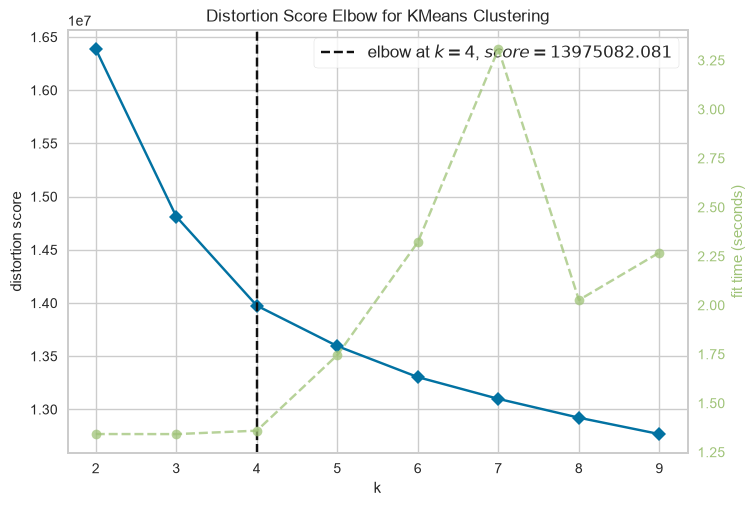

In [62]:
# Initializing the cluster algorithm
KClusterer = KMeans(random_state = 2025)


KClusterer._estimator_type = "clusterer"
visualizer = KElbowVisualizer(KClusterer, k=(2,10))
visualizer.fit(X)
visualizer.show()
# Initialize the elbow visualizer.
# This code was basically copied straight from Mar.20 lab.
visualizer = KElbowVisualizer(KClusterer, # Cluster model with any parameters you need
                              k = (2, 12), # Number of clusters to test (2 to 12 in this case)
                              locate_elbow = True, # Locate the elbow? Default is true.
                              timings = False # Plot the timings to train?
                             )

#visualizer.fit(X) # Fit the visualizer
#visualizer.show()

## Silhouette Scores

Two Approaches below:
1. Calculates Silhouette score and also provides Silhouette graph
2. Calculates Average Silhouette scores and presents them without a graph. There is a final graph that shows all scores at the end of run.

*Currently Commented out since it takes a long time to run*

In [ ]:
# # Silhouette with graphs
# # Takes too long to run

# # Loop through cluster counts from 2 to 9.
# for n_clusters in range(2, 10):
#     print("="*50)
#     print(f"Evaluating KMeans with {n_clusters} clusters")

#     # Create a pipeline: scale data and then apply KMeans.
#     kmeans_pipe = Pipeline([
#         # ('scale', StandardScaler()), # X is already scaled in a cell above
#         ('kmeans', KMeans(n_clusters=n_clusters, n_init=10, random_state=2025))
#     ])

#     # Fit the pipeline to the training data.
#     kmeans_pipe.fit(X)

#     # Predict the cluster labels.
#     cluster_labels = kmeans_pipe.predict(X)

#     # Transform X_train using the scaler from the pipeline.
#     # X_train_scaled = kmeans_pipe.named_steps['scale'].transform(X_train_scaled)

#     # Calculate the average silhouette score.
#     sil_score = silhouette_score(X, cluster_labels)
#     print(f"Average silhouette score for k = {n_clusters}: {sil_score:.3f}")

#     # Initialize and fit the Yellowbrick SilhouetteVisualizer.
#     kmeans_model = kmeans_pipe.named_steps['kmeans']
#     kmeans_model._estimator_type = "clusterer" 
#     visualizer = SilhouetteVisualizer(kmeans_model, colors='yellowbrick')
#     visualizer.fit(X)
#     visualizer.show()

In [ ]:
# # Only Silhouette Averages are calculated here
# # has a graph to show at the end (Not silhouette graph)
# # Takes too long to run

# silhouette_avgs = []

# # Loop through cluster counts from 2 to 13.
# for n_clusters in range(2, 9):
#     # Initialize and fit the KMeans model
#     kmeans = KMeans(n_clusters=n_clusters, n_init=10, random_state=2025)
#     cluster_labels = kmeans.fit_predict(X)

#     # Calculate the average silhouette score for the current number of clusters
#     silhouette_avg = silhouette_score(X, cluster_labels)
#     silhouette_avgs.append(silhouette_avg)
#     print(f"For n_clusters = {n_clusters}, the average silhouette score is {silhouette_avg:.4f}")

## Fit Final KMeans and Assign Labels

In [66]:
# Now that we've determined the optimal number of clusters, fit the final K-means

# Initialize and fit K-means
KClusterer = KMeans(n_clusters = 2, random_state = 2025)
KClusterer.fit(X)

# Get cluster labels for plotting later on
# This tells matplotlib or seaborn what colour each observation should be, based on cluster membership
labels = KClusterer.labels_

## Dimensionality Reduction with PCA

In [67]:
# Principal component analysis

# Initialize PCA with 5 PCs.
pca = PCA(n_components = 5)

# Fit PCA to the standardized data and transform
X_pca = pca.fit_transform(X)

In [68]:
# Look at the proportion of explain variance associated with each PC
# PC1 explains most of the variance
print(pca.explained_variance_ratio_)

[0.44259761 0.03677905 0.03460879 0.01854492 0.01517594]


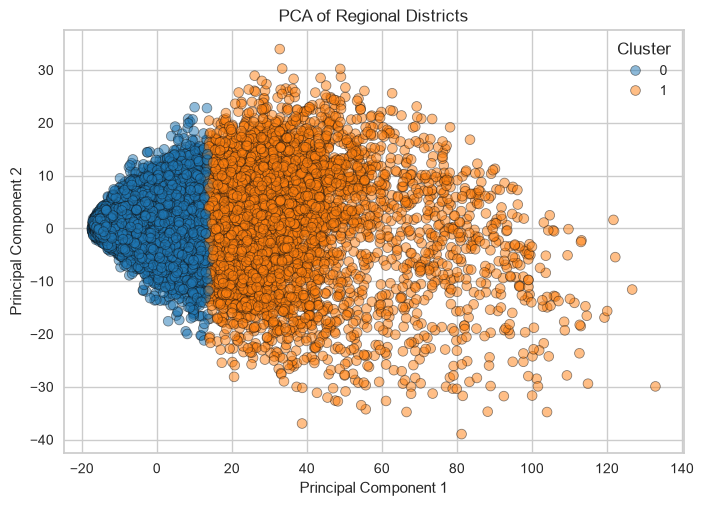

In [69]:
# Create a new Seaborn scatter plot
sns.scatterplot(
    x = X_pca[:, 0], # PC1
    y = X_pca[:, 1], # PC2
    hue = labels, # Base the number of unique legend colours on the labels we saved previously
    palette = 'tab10',
    alpha = 0.5,
    edgecolor = 'k'
)

plt.title("PCA of Regional Districts")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title = 'Cluster', loc = 'best')

## Interpret PCA Loadings

In [70]:
# Create a dataframe from PCA output using the first 3 components
# If changing the number of components, change the slicing of X_pca accordingly
df_pca = pd.DataFrame(X_pca[:, 0:3], columns = ["PC1", "PC2", "PC3"])

# Add cluster labels (which were stored previously)
df_pca["cluster"] = labels

# Group by cluster and compute average of each PC
# Apparently we don't need .agg() here because .mean() already does that
cluster_avg = df_pca.groupby("cluster").mean()

# Display the result
print(cluster_avg)

# Based on the PC loadings analysis below:
# Cluster 0: Slightly larger than average population, some cultural diversity, average incomes
# Cluster 1: Very large population but low-income and low-diversity
# Cluster 2: Large multicultural neighbourhoods with decent incomes
# Cluster 3: Slightly smaller than average population, average diversity and incomes

               PC1       PC2       PC3
cluster                               
0        -7.614264 -0.145698 -0.203723
1        35.284532  0.675166  0.944054


In [71]:
# Get colnames from original dataframe without "CODE" column
feature_names = df_train_cleaned_clustering.drop("CODE").columns

# Create a dataframe of PCA loadings
loadings = pd.DataFrame(pca.components_,
                        columns = feature_names, # Set variable names as column labels
                        index = [f"PC{i+1}" for i in range(pca.n_components_)]) # Name rows as PC1, PC2, etc.

print(loadings)


     HSBASHHD  HSAGDISPIN  HSAGDISCIN   HSTT001   HSTE001   HSTX001   HSTC001  \
PC1  0.044920    0.047109    0.046575  0.046101  0.046495  0.040391  0.047390   
PC2  0.016340   -0.030267   -0.035981 -0.041104 -0.034084 -0.049222 -0.028548   
PC3 -0.058895    0.001032    0.000912  0.023888  0.009477  0.031596  0.002403   
PC4  0.011610    0.016537    0.018726  0.016849  0.020359  0.040497  0.014215   
PC5 -0.001243    0.021600    0.023166  0.027731  0.032760  0.061690  0.022147   

     HSSH001S  HSFD001S  HSHO001S  ...  ECYGEN1GEN  ECYGEN2GEN  ECYGEN3GEN  \
PC1  0.047007  0.047512  0.047193  ...    0.033802    0.042352    0.035913   
PC2 -0.016002 -0.025958 -0.027885  ...    0.079790    0.030260   -0.051930   
PC3  0.012093 -0.007682 -0.001629  ...    0.046900    0.036598   -0.058136   
PC4  0.019021  0.008494  0.015162  ...    0.059837    0.010427   -0.057047   
PC5  0.021803  0.016451  0.018172  ...    0.000823   -0.031637    0.009715   

     ECYTCAHPOP  ECYTCACIT  ECYTCA_U18  ECYT

In [72]:
# Making a dataframe of variable names and their descriptions
# This will be used for matching variable descriptions to their codes
# when inspecting PC loadings.
demo_metadata = pd.read_csv(r"C:\Users\musta\Documents\Projects\household data dashboard\Data\DemoStats 2024 - Metadata.csv")
# demo_metadata = pd.read_csv("D:\\ds_3000_project\\DemoStats 2024 - Metadata.csv") # For local work
demo_metadata = demo_metadata[["Variable", "Description"]]

household_metadata = pd.read_csv(r"C:\Users\musta\Documents\Projects\household data dashboard\Data\HouseholdSpend 2024 - Metadata.csv")
# household_metadata = pd.read_csv("D:\\ds_3000_project\\coursework_data/HouseholdSpend 2024 - Metadata.csv")
household_metadata = household_metadata[["Variable", "Description"]]
household_metadata = household_metadata.drop([0, 1]) # Drop the first two rows because they already exist in the demographics metadata
household_metadata = household_metadata.reset_index(drop = True) # Reset the index

metadata_df = pd.concat([demo_metadata, household_metadata], ignore_index = True)

In [73]:
# Inspecting the loadings for PC1
(loadings.loc["PC1"]
    .sort_values(ascending = False)
    .reset_index().rename(columns = {"index" : "Variable"})
    .merge(metadata_df, on = "Variable", how = "left")
    .head(20))

# Based on the loadings, we'd call PC1 "Neighbourhoods with large populations"

,Variable,PC1,Description
0,ECYMOBHPOP,0.048086,Household Population For 5 Year Mobility Status
1,ECYHOMSING,0.048084,Single Responses
2,ECYHTAHPOP,0.048082,Household Population
3,ECYTIMHPOP,0.048082,Total Household Population
4,ECYAIDHPOP,0.048082,Household Population For Indigenous Identity
5,ECYKNOHPOP,0.048082,Household Population For Knowledge Of Official...
6,ECYVISHPOP,0.048082,Household Population For Visible Minority
7,ECYRELHPOP,0.048082,Household Population For Religion
8,ECYMOTHPOP,0.048082,Household Population For Mother Tongue
9,ECYBASHPOP,0.048082,Total Household Population


In [74]:
# Inspecting the loadings for PC2
(loadings.loc["PC2"]
    .sort_values(ascending = False)
    .reset_index().rename(columns = {"index" : "Variable"})
    .merge(metadata_df, on = "Variable", how = "left")
    .head(20))

# Based on the loadings, we'd call PC2 "High Presence of Immigrant Households"

,Variable,PC2,Description
0,ECYNCA_18P,0.082664,Non-Citizens 18 Or Older
1,ECYNCANCIT,0.082218,Total Non-Citizens
2,ECYVISVM,0.081691,Visible Minority Total
3,ECYHOMNOFF,0.081636,Non-Official Languages
4,ECYGEN1GEN,0.079790,First Generation
5,ECYMOTNOFF,0.077266,Total Non-Official
6,ECYHOMMULT,0.076920,Multiple Languages
7,ECYPIM1621,0.076123,2016 To 2021
8,ECYAIM2544,0.074216,25 To 44 Years
9,ECYTIMIMGT,0.073807,Total Immigrant


In [75]:
# Inspecting the loadings for PC3
(loadings.loc["PC3"]
    .sort_values(ascending = False)
    .reset_index().rename(columns = {"index" : "Variable"})
    .merge(metadata_df, on = "Variable", how = "left")
    .head(20))

# Based on the loadings, we'd call PC2 "Wealthy Neighbourhoods"

,Variable,PC3,Description
0,ECYHSZAVG,0.107568,Average Number Of Persons In Private Households
1,HSWH040S,0.107262,Net purchase price of owned residences
2,HSTE001ZBS,0.100081,Total non-current consumption
3,ECYHRIAVG,0.092582,Average Household Income (Constant Year 2020 $)
4,ECYHNIAVG,0.092582,Average Household Income (Current Year $)
5,HSSH033A,0.090359,Natural gas charges for owned principal residence
6,ECYHRIMED,0.089866,Median Household Income (Constant Year 2020 $)
7,ECYHNIMED,0.088135,Median Household Income (Current Year $)
8,ECYCHAHHCH,0.085497,Average Children Per Household
9,HSSH033,0.085197,Natural gas


## Alternative Visualization Using UMAP

In [76]:
import sklearn
print(sklearn.__version__)

1.9.1


In [77]:
%pip install umap-learn
import umap


# Store best results
best_silhouette = -1
best_embedding = None
best_params = {}

# Try combinations of neighbors and min_dist
neighbors_options = [10, 30, 50]
min_dist_options = [0.0, 0.3, 0.8]

for n in neighbors_options:
    for d in min_dist_options:
        print(f"Training UMAP with n_neighbors={n}, min_dist={d}...")

        # Create UMAP object
        reducer = umap.UMAP(n_neighbors=n,
                            n_components=2,
                            metric='cosine',
                            n_epochs=1000,
                            min_dist=d,
                            spread=1.0,
                            low_memory=False,
                            n_jobs=-1,
                            verbose=True,
                            random_state=2025)

        # Train UMAP and get embedding
        embedding = reducer.fit_transform(X)

        # Evaluate using silhouette score
        score = silhouette_score(embedding, labels)
        print(f"Silhouette Score: {score:.4f}")

        # Save if it's the best so far
        if score > best_silhouette:
            best_silhouette = score
            best_embedding = embedding
            best_params = {'n_neighbors': n, 'min_dist': d}

# Output best result
print("\nBest UMAP Parameters:")
print(best_params)
print(f"Best Silhouette Score: {best_silhouette:.4f}")

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Training UMAP with n_neighbors=10, min_dist=0.0...
UMAP(angular_rp_forest=True, low_memory=False, metric='cosine', min_dist=0.0, n_epochs=1000, n_jobs=1, n_neighbors=10, random_state=2025, verbose=True)


c:\Users\musta\AppData\Local\Python\pythoncore-3.11-64\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Fri Sep 18 12:16:31 2026 Construct fuzzy simplicial set
Fri Sep 18 12:16:31 2026 Finding Nearest Neighbors
Fri Sep 18 12:16:31 2026 Building RP forest with 13 trees
Fri Sep 18 12:16:46 2026 NN descent for 15 iterations
	 1  /  15
	 2  /  15
	 3  /  15
	 4  /  15
	 5  /  15
	 6  /  15
	 7  /  15
	Stopping threshold met -- exiting after 7 iterations
Fri Sep 18 12:17:17 2026 Finished Nearest Neighbor Search
Fri Sep 18 12:17:27 2026 Construct embedding


Epochs completed:   0%|            4/1000 [00:01]

	completed  0  /  1000 epochs


Epochs completed:  10%| █          102/1000 [00:11]

	completed  100  /  1000 epochs


Epochs completed:  20%| ██         202/1000 [00:21]

	completed  200  /  1000 epochs


Epochs completed:  30%| ███        304/1000 [00:30]

	completed  300  /  1000 epochs


Epochs completed:  40%| ████       402/1000 [00:40]

	completed  400  /  1000 epochs


Epochs completed:  50%| █████      502/1000 [00:50]

	completed  500  /  1000 epochs


Epochs completed:  60%| ██████     601/1000 [01:00]

	completed  600  /  1000 epochs


Epochs completed:  70%| ███████    701/1000 [01:09]

	completed  700  /  1000 epochs


Epochs completed:  80%| ████████   801/1000 [01:19]

	completed  800  /  1000 epochs


Epochs completed:  90%| █████████  902/1000 [01:29]

	completed  900  /  1000 epochs


Epochs completed: 100%| ██████████ 1000/1000 [01:39]


Fri Sep 18 12:19:07 2026 Finished embedding
Silhouette Score: 0.3507
Training UMAP with n_neighbors=10, min_dist=0.3...
UMAP(angular_rp_forest=True, low_memory=False, metric='cosine', min_dist=0.3, n_epochs=1000, n_jobs=1, n_neighbors=10, random_state=2025, verbose=True)
Fri Sep 18 12:19:26 2026 Construct fuzzy simplicial set


c:\Users\musta\AppData\Local\Python\pythoncore-3.11-64\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Fri Sep 18 12:19:26 2026 Finding Nearest Neighbors
Fri Sep 18 12:19:26 2026 Building RP forest with 13 trees
Fri Sep 18 12:19:29 2026 NN descent for 15 iterations
	 1  /  15
	 2  /  15
	 3  /  15
	 4  /  15
	 5  /  15
	 6  /  15
	 7  /  15
	Stopping threshold met -- exiting after 7 iterations
Fri Sep 18 12:19:35 2026 Finished Nearest Neighbor Search
Fri Sep 18 12:19:35 2026 Construct embedding


Epochs completed:   0%|            4/1000 [00:00]

	completed  0  /  1000 epochs


Epochs completed:  10%| █          102/1000 [00:09]

	completed  100  /  1000 epochs


Epochs completed:  20%| ██         202/1000 [00:19]

	completed  200  /  1000 epochs


Epochs completed:  30%| ███        302/1000 [00:29]

	completed  300  /  1000 epochs


Epochs completed:  40%| ████       402/1000 [00:38]

	completed  400  /  1000 epochs


Epochs completed:  50%| █████      504/1000 [00:48]

	completed  500  /  1000 epochs


Epochs completed:  60%| ██████     603/1000 [00:58]

	completed  600  /  1000 epochs


Epochs completed:  70%| ███████    703/1000 [01:08]

	completed  700  /  1000 epochs


Epochs completed:  80%| ████████   803/1000 [01:17]

	completed  800  /  1000 epochs


Epochs completed:  90%| █████████  905/1000 [01:27]

	completed  900  /  1000 epochs


Epochs completed: 100%| ██████████ 1000/1000 [01:36]


Fri Sep 18 12:21:13 2026 Finished embedding
Silhouette Score: 0.3201
Training UMAP with n_neighbors=10, min_dist=0.8...
UMAP(angular_rp_forest=True, low_memory=False, metric='cosine', min_dist=0.8, n_epochs=1000, n_jobs=1, n_neighbors=10, random_state=2025, verbose=True)
Fri Sep 18 12:21:33 2026 Construct fuzzy simplicial set


c:\Users\musta\AppData\Local\Python\pythoncore-3.11-64\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Fri Sep 18 12:21:33 2026 Finding Nearest Neighbors
Fri Sep 18 12:21:33 2026 Building RP forest with 13 trees
Fri Sep 18 12:21:35 2026 NN descent for 15 iterations
	 1  /  15
	 2  /  15
	 3  /  15
	 4  /  15
	 5  /  15
	 6  /  15
	 7  /  15
	Stopping threshold met -- exiting after 7 iterations
Fri Sep 18 12:21:42 2026 Finished Nearest Neighbor Search
Fri Sep 18 12:21:42 2026 Construct embedding


Epochs completed:   0%|            4/1000 [00:00]

	completed  0  /  1000 epochs


Epochs completed:  10%| █          102/1000 [00:09]

	completed  100  /  1000 epochs


Epochs completed:  20%| ██         202/1000 [00:19]

	completed  200  /  1000 epochs


Epochs completed:  30%| ███        304/1000 [00:29]

	completed  300  /  1000 epochs


Epochs completed:  40%| ████       401/1000 [00:39]

	completed  400  /  1000 epochs


Epochs completed:  50%| █████      501/1000 [00:49]

	completed  500  /  1000 epochs


Epochs completed:  60%| ██████     601/1000 [00:59]

	completed  600  /  1000 epochs


Epochs completed:  70%| ███████    702/1000 [01:10]

	completed  700  /  1000 epochs


Epochs completed:  80%| ████████   804/1000 [01:20]

	completed  800  /  1000 epochs


Epochs completed:  90%| █████████  901/1000 [01:29]

	completed  900  /  1000 epochs


Epochs completed: 100%| ██████████ 1000/1000 [01:39]


Fri Sep 18 12:23:22 2026 Finished embedding
Silhouette Score: 0.3257
Training UMAP with n_neighbors=30, min_dist=0.0...
UMAP(angular_rp_forest=True, low_memory=False, metric='cosine', min_dist=0.0, n_epochs=1000, n_jobs=1, n_neighbors=30, random_state=2025, verbose=True)


c:\Users\musta\AppData\Local\Python\pythoncore-3.11-64\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Fri Sep 18 12:23:43 2026 Construct fuzzy simplicial set
Fri Sep 18 12:23:43 2026 Finding Nearest Neighbors
Fri Sep 18 12:23:43 2026 Building RP forest with 13 trees
Fri Sep 18 12:23:48 2026 NN descent for 15 iterations
	 1  /  15
	 2  /  15
	 3  /  15
	 4  /  15
	 5  /  15
	Stopping threshold met -- exiting after 5 iterations
Fri Sep 18 12:24:12 2026 Finished Nearest Neighbor Search
Fri Sep 18 12:24:13 2026 Construct embedding


Epochs completed:   0%|            4/1000 [00:00]

	completed  0  /  1000 epochs


Epochs completed:  10%| █          103/1000 [00:14]

	completed  100  /  1000 epochs


Epochs completed:  20%| ██         202/1000 [00:29]

	completed  200  /  1000 epochs


Epochs completed:  30%| ███        303/1000 [00:44]

	completed  300  /  1000 epochs


Epochs completed:  40%| ████       402/1000 [00:59]

	completed  400  /  1000 epochs


Epochs completed:  50%| █████      502/1000 [01:13]

	completed  500  /  1000 epochs


Epochs completed:  60%| ██████     602/1000 [01:28]

	completed  600  /  1000 epochs


Epochs completed:  70%| ███████    702/1000 [01:43]

	completed  700  /  1000 epochs


Epochs completed:  80%| ████████   802/1000 [01:58]

	completed  800  /  1000 epochs


Epochs completed:  90%| █████████  902/1000 [02:13]

	completed  900  /  1000 epochs


Epochs completed: 100%| ██████████ 1000/1000 [02:27]


Fri Sep 18 12:26:42 2026 Finished embedding
Silhouette Score: 0.3766
Training UMAP with n_neighbors=30, min_dist=0.3...
UMAP(angular_rp_forest=True, low_memory=False, metric='cosine', min_dist=0.3, n_epochs=1000, n_jobs=1, n_neighbors=30, random_state=2025, verbose=True)
Fri Sep 18 12:27:02 2026 Construct fuzzy simplicial set


c:\Users\musta\AppData\Local\Python\pythoncore-3.11-64\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Fri Sep 18 12:27:02 2026 Finding Nearest Neighbors
Fri Sep 18 12:27:02 2026 Building RP forest with 13 trees
Fri Sep 18 12:27:05 2026 NN descent for 15 iterations
	 1  /  15
	 2  /  15
	 3  /  15
	 4  /  15
	 5  /  15
	Stopping threshold met -- exiting after 5 iterations
Fri Sep 18 12:27:29 2026 Finished Nearest Neighbor Search
Fri Sep 18 12:27:29 2026 Construct embedding


Epochs completed:   0%|            3/1000 [00:00]

	completed  0  /  1000 epochs


Epochs completed:  10%| █          102/1000 [00:14]

	completed  100  /  1000 epochs


Epochs completed:  20%| ██         202/1000 [00:29]

	completed  200  /  1000 epochs


Epochs completed:  30%| ███        303/1000 [00:44]

	completed  300  /  1000 epochs


Epochs completed:  40%| ████       403/1000 [00:58]

	completed  400  /  1000 epochs


Epochs completed:  50%| █████      502/1000 [01:13]

	completed  500  /  1000 epochs


Epochs completed:  60%| ██████     602/1000 [01:28]

	completed  600  /  1000 epochs


Epochs completed:  70%| ███████    702/1000 [01:43]

	completed  700  /  1000 epochs


Epochs completed:  80%| ████████   802/1000 [01:57]

	completed  800  /  1000 epochs


Epochs completed:  90%| █████████  902/1000 [02:12]

	completed  900  /  1000 epochs


Epochs completed: 100%| ██████████ 1000/1000 [02:27]


Fri Sep 18 12:29:58 2026 Finished embedding
Silhouette Score: 0.3387
Training UMAP with n_neighbors=30, min_dist=0.8...
UMAP(angular_rp_forest=True, low_memory=False, metric='cosine', min_dist=0.8, n_epochs=1000, n_jobs=1, n_neighbors=30, random_state=2025, verbose=True)
Fri Sep 18 12:30:17 2026 Construct fuzzy simplicial set


c:\Users\musta\AppData\Local\Python\pythoncore-3.11-64\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Fri Sep 18 12:30:17 2026 Finding Nearest Neighbors
Fri Sep 18 12:30:17 2026 Building RP forest with 13 trees
Fri Sep 18 12:30:20 2026 NN descent for 15 iterations
	 1  /  15
	 2  /  15
	 3  /  15
	 4  /  15
	 5  /  15
	Stopping threshold met -- exiting after 5 iterations
Fri Sep 18 12:30:45 2026 Finished Nearest Neighbor Search
Fri Sep 18 12:30:46 2026 Construct embedding


Epochs completed:   1%|            6/1000 [00:00]

	completed  0  /  1000 epochs


Epochs completed:  10%| █          102/1000 [00:14]

	completed  100  /  1000 epochs


Epochs completed:  20%| ██         202/1000 [00:30]

	completed  200  /  1000 epochs


Epochs completed:  30%| ███        302/1000 [00:45]

	completed  300  /  1000 epochs


Epochs completed:  40%| ████       403/1000 [01:00]

	completed  400  /  1000 epochs


Epochs completed:  50%| █████      502/1000 [01:15]

	completed  500  /  1000 epochs


Epochs completed:  60%| ██████     603/1000 [01:31]

	completed  600  /  1000 epochs


Epochs completed:  70%| ███████    702/1000 [01:46]

	completed  700  /  1000 epochs


Epochs completed:  80%| ████████   803/1000 [02:01]

	completed  800  /  1000 epochs


Epochs completed:  90%| █████████  903/1000 [02:16]

	completed  900  /  1000 epochs


Epochs completed: 100%| ██████████ 1000/1000 [02:31]


Fri Sep 18 12:33:19 2026 Finished embedding
Silhouette Score: 0.3388
Training UMAP with n_neighbors=50, min_dist=0.0...
UMAP(angular_rp_forest=True, low_memory=False, metric='cosine', min_dist=0.0, n_epochs=1000, n_jobs=1, n_neighbors=50, random_state=2025, verbose=True)


c:\Users\musta\AppData\Local\Python\pythoncore-3.11-64\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Fri Sep 18 12:33:39 2026 Construct fuzzy simplicial set
Fri Sep 18 12:33:39 2026 Finding Nearest Neighbors
Fri Sep 18 12:33:39 2026 Building RP forest with 13 trees
Fri Sep 18 12:33:42 2026 NN descent for 15 iterations
	 1  /  15
	 2  /  15
	 3  /  15
	 4  /  15
	Stopping threshold met -- exiting after 4 iterations
Fri Sep 18 12:34:27 2026 Finished Nearest Neighbor Search
Fri Sep 18 12:34:28 2026 Construct embedding


Epochs completed:   1%|            6/1000 [00:00]

	completed  0  /  1000 epochs


Epochs completed:  10%| █          102/1000 [00:17]

	completed  100  /  1000 epochs


Epochs completed:  20%| ██         202/1000 [00:35]

	completed  200  /  1000 epochs


Epochs completed:  30%| ███        302/1000 [00:52]

	completed  300  /  1000 epochs


Epochs completed:  40%| ████       402/1000 [01:10]

	completed  400  /  1000 epochs


Epochs completed:  50%| █████      501/1000 [01:28]

	completed  500  /  1000 epochs


Epochs completed:  60%| ██████     602/1000 [01:46]

	completed  600  /  1000 epochs


Epochs completed:  70%| ███████    702/1000 [02:04]

	completed  700  /  1000 epochs


Epochs completed:  80%| ████████   801/1000 [02:25]

	completed  800  /  1000 epochs


Epochs completed:  90%| █████████  902/1000 [02:45]

	completed  900  /  1000 epochs


Epochs completed: 100%| ██████████ 1000/1000 [03:02]


Fri Sep 18 12:37:32 2026 Finished embedding
Silhouette Score: 0.3919
Training UMAP with n_neighbors=50, min_dist=0.3...
UMAP(angular_rp_forest=True, low_memory=False, metric='cosine', min_dist=0.3, n_epochs=1000, n_jobs=1, n_neighbors=50, random_state=2025, verbose=True)


c:\Users\musta\AppData\Local\Python\pythoncore-3.11-64\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Fri Sep 18 12:37:52 2026 Construct fuzzy simplicial set
Fri Sep 18 12:37:52 2026 Finding Nearest Neighbors
Fri Sep 18 12:37:52 2026 Building RP forest with 13 trees
Fri Sep 18 12:37:55 2026 NN descent for 15 iterations
	 1  /  15
	 2  /  15
	 3  /  15
	 4  /  15
	Stopping threshold met -- exiting after 4 iterations
Fri Sep 18 12:38:41 2026 Finished Nearest Neighbor Search
Fri Sep 18 12:38:42 2026 Construct embedding


Epochs completed:   1%|            6/1000 [00:00]

	completed  0  /  1000 epochs


Epochs completed:  10%| █          101/1000 [00:17]

	completed  100  /  1000 epochs


Epochs completed:  20%| ██         201/1000 [00:34]

	completed  200  /  1000 epochs


Epochs completed:  30%| ███        302/1000 [00:52]

	completed  300  /  1000 epochs


Epochs completed:  40%| ████       402/1000 [01:09]

	completed  400  /  1000 epochs


Epochs completed:  50%| █████      502/1000 [01:27]

	completed  500  /  1000 epochs


Epochs completed:  60%| ██████     602/1000 [01:44]

	completed  600  /  1000 epochs


Epochs completed:  70%| ███████    703/1000 [02:01]

	completed  700  /  1000 epochs


Epochs completed:  80%| ████████   802/1000 [02:19]

	completed  800  /  1000 epochs


Epochs completed:  90%| █████████  903/1000 [02:36]

	completed  900  /  1000 epochs


Epochs completed: 100%| ██████████ 1000/1000 [02:53]


Fri Sep 18 12:41:37 2026 Finished embedding
Silhouette Score: 0.3489
Training UMAP with n_neighbors=50, min_dist=0.8...


c:\Users\musta\AppData\Local\Python\pythoncore-3.11-64\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP(angular_rp_forest=True, low_memory=False, metric='cosine', min_dist=0.8, n_epochs=1000, n_jobs=1, n_neighbors=50, random_state=2025, verbose=True)
Fri Sep 18 12:41:57 2026 Construct fuzzy simplicial set
Fri Sep 18 12:41:58 2026 Finding Nearest Neighbors
Fri Sep 18 12:41:58 2026 Building RP forest with 13 trees
Fri Sep 18 12:42:00 2026 NN descent for 15 iterations
	 1  /  15
	 2  /  15
	 3  /  15
	 4  /  15
	Stopping threshold met -- exiting after 4 iterations
Fri Sep 18 12:42:47 2026 Finished Nearest Neighbor Search
Fri Sep 18 12:42:48 2026 Construct embedding


Epochs completed:   0%|            3/1000 [00:00]

	completed  0  /  1000 epochs


Epochs completed:  10%| █          102/1000 [00:17]

	completed  100  /  1000 epochs


Epochs completed:  20%| ██         201/1000 [00:35]

	completed  200  /  1000 epochs


Epochs completed:  30%| ███        302/1000 [00:52]

	completed  300  /  1000 epochs


Epochs completed:  40%| ████       401/1000 [01:09]

	completed  400  /  1000 epochs


Epochs completed:  50%| █████      502/1000 [01:28]

	completed  500  /  1000 epochs


Epochs completed:  60%| ██████     601/1000 [01:45]

	completed  600  /  1000 epochs


Epochs completed:  70%| ███████    702/1000 [02:04]

	completed  700  /  1000 epochs


Epochs completed:  80%| ████████   802/1000 [02:22]

	completed  800  /  1000 epochs


Epochs completed:  90%| █████████  902/1000 [02:41]

	completed  900  /  1000 epochs


Epochs completed: 100%| ██████████ 1000/1000 [02:58]


Fri Sep 18 12:45:48 2026 Finished embedding
Silhouette Score: 0.3456

Best UMAP Parameters:
{'n_neighbors': 50, 'min_dist': 0.0}
Best Silhouette Score: 0.3919


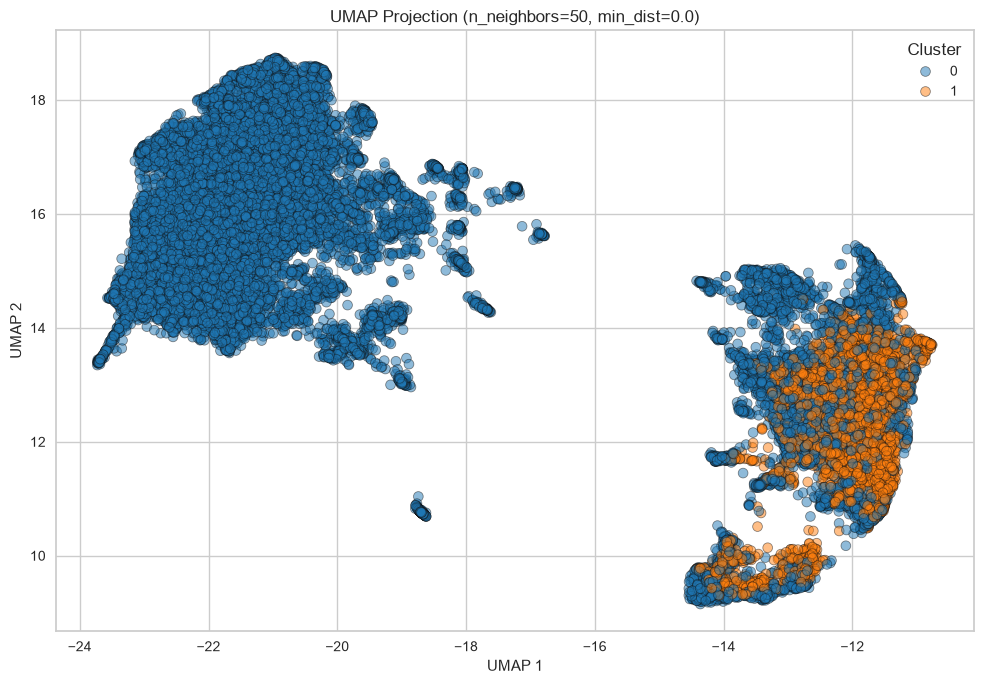

In [78]:
# Plot final UMAP embedding
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x = best_embedding[:, 0],
    y = best_embedding[:, 1],
    hue = labels,
    palette = 'tab10',
    alpha = 0.5,
    edgecolor = 'k'
)

plt.title(f"UMAP Projection (n_neighbors={best_params['n_neighbors']}, min_dist={best_params['min_dist']})")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.legend(title='Cluster')
plt.grid(True)
plt.tight_layout()
plt.show()

# Regression Modeling – Part 2 of Assignment
- Predict insurance & pension contributions as a proportion of income.

## Train/Validation Split (commented out because I made the validation set earlier now)

## Create Target Variable

In [79]:
target_col_name = "insurance_pension_ratio"
col_contrib = "HSEP001S"
col_income = "HSHNIAGG"

# Function to calculate the ratio
def calculate_target(df, contrib_col, income_col, target_name):
    return df.with_columns(
        (pl.col(contrib_col) / pl.col(income_col)).alias(target_name)
    )

# Calculate targets for train, val, and test
df_train_final_xgb = calculate_target(train_df.drop("CODE"), col_contrib, col_income, target_col_name)
df_val_xgb = calculate_target(val_df.drop("CODE"), col_contrib, col_income, target_col_name)
df_test_xgb = calculate_target(test_df.drop("CODE"), col_contrib, col_income, target_col_name)

In [80]:
# Checking target variable descriptive stats
print("Target Variable Descriptive Statistics (Training Set):")
print(df_train_final_xgb.select(target_col_name).describe())

print("Target Variable Descriptive Statistics (Validation Set):")
print(df_val_xgb.select(target_col_name).describe())

print("\nTarget Variable Descriptive Statistics (Test Set):")
print(df_test_xgb.select(target_col_name).describe())

Target Variable Descriptive Statistics (Training Set):
shape: (9, 2)
┌────────────┬─────────────────────────┐
│ statistic  ┆ insurance_pension_ratio │
│ ---        ┆ ---                     │
│ str        ┆ f64                     │
╞════════════╪═════════════════════════╡
│ count      ┆ 54279.0                 │
│ null_count ┆ 0.0                     │
│ mean       ┆ 0.053735                │
│ std        ┆ 0.015751                │
│ min        ┆ 0.002876                │
│ 25%        ┆ 0.044615                │
│ 50%        ┆ 0.054107                │
│ 75%        ┆ 0.063436                │
│ max        ┆ 0.137333                │
└────────────┴─────────────────────────┘
Target Variable Descriptive Statistics (Validation Set):
shape: (9, 2)
┌────────────┬─────────────────────────┐
│ statistic  ┆ insurance_pension_ratio │
│ ---        ┆ ---                     │
│ str        ┆ f64                     │
╞════════════╪═════════════════════════╡
│ count      ┆ 11631.0                 │

## Extract Final Features and Targets for Modeling

In [81]:
# Drop unnecessary columns
cols_to_drop_for_xgb = [target_col_name, col_contrib, col_income]

# Extract features and target for training and validation
X_train_pl = df_train_final_xgb.drop(cols_to_drop_for_xgb)
y_train_pl = df_train_final_xgb.select(target_col_name)

X_val_pl = df_val_xgb.drop(cols_to_drop_for_xgb)
y_val_pl = df_val_xgb.select(target_col_name)

X_test_pl = df_test_xgb.drop(cols_to_drop_for_xgb)
y_test_pl = df_test_xgb.select(target_col_name)

# Convert to pandas/numpy
X_train = X_train_pl.to_pandas()
y_train = y_train_pl.to_numpy().ravel()

X_val = X_val_pl.to_pandas()
y_val = y_val_pl.to_numpy().ravel()

X_test = X_test_pl.to_pandas()
y_test = y_test_pl.to_numpy().ravel()

In [82]:
print(f"\nFeature shapes: X_train={X_train.shape}, X_val={X_val.shape}, X_test={X_test.shape}")
print(f"Target shapes: y_train={y_train.shape}, y_val={y_val.shape}, y_test={y_test.shape}")


Feature shapes: X_train=(54279, 967), X_val=(11631, 967), X_test=(11632, 967)
Target shapes: y_train=(54279,), y_val=(11631,), y_test=(11632,)


Beginning of PCA Elastic Net code

In [83]:
# Select only numeric columns from X_train and X_test
# X_train = X_train.select(pl.col(pl.NUMERIC_DTYPES))
# X_val = X_val.select(pl.col(pl.NUMERIC_DTYPES))
# X_test = X_test.select(pl.col(pl.NUMERIC_DTYPES))

# print("Scaling Data")

# Initialize the StandardScaler
scaler = StandardScaler()
# Fit the scaler to the training data and transform both training and test data
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Scaling Completed")

Scaling Completed


In [84]:
# X_train_scaled is scaled training data.
pca_full = PCA(n_components=None, random_state=2025)
pca_full.fit(X_train_scaled)

# Get cumulative explained variance for all components
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

for i in range(1, 9):
    variance = cumulative_variance[i * 100 - 1]
    info_loss = 1 - variance
    print(f"Variance retained with {i * 100} components: {variance:.6%}")
    print(f"Information lost with {i * 100} components: {info_loss:.6%}")

Variance retained with 100 components: 89.999359%
Information lost with 100 components: 10.000641%
Variance retained with 200 components: 96.226159%
Information lost with 200 components: 3.773841%
Variance retained with 300 components: 98.735525%
Information lost with 300 components: 1.264475%
Variance retained with 400 components: 99.624877%
Information lost with 400 components: 0.375123%
Variance retained with 500 components: 99.928703%
Information lost with 500 components: 0.071297%
Variance retained with 600 components: 99.997650%
Information lost with 600 components: 0.002350%
Variance retained with 700 components: 100.000000%
Information lost with 700 components: -0.000000%
Variance retained with 800 components: 100.000000%
Information lost with 800 components: -0.000000%


In [85]:
# First ensure that data is in NumPy format for scikitlearn
def ensure_numpy(data):
    if isinstance(data, pd.DataFrame):
        return data.values
    elif hasattr(data, "to_numpy"):
        return data.to_numpy()
    return data

X_train_scaled = ensure_numpy(X_train_scaled)
y_train = ensure_numpy(y_train)
X_val_scaled = ensure_numpy(X_val_scaled)
y_val = ensure_numpy(y_val)

print("Data shapes:")
print("  X_train_scaled:", X_train_scaled.shape)
print("  y_train:", y_train.shape)
print("  X_val_scaled:", X_val_scaled.shape)
print("  y_val:", y_val.shape)

Data shapes:
  X_train_scaled: (54279, 967)
  y_train: (54279,)
  X_val_scaled: (11631, 967)
  y_val: (11631,)


In [86]:
# (Optional) Subsample Training Data for Grid Search
subsample_size = 20000
if X_train_scaled.shape[0] > subsample_size:
    np.random.seed(2025)
    sample_indices = np.random.choice(X_train_scaled.shape[0], subsample_size, replace=False)
    X_train_sub = X_train_scaled[sample_indices]
    y_train_sub = y_train[sample_indices]
else:
    X_train_sub = X_train_scaled
    y_train_sub = y_train

print("Subsample shapes:")
print("  X_train_sub:", X_train_sub.shape)
print("  y_train_sub:", y_train_sub.shape)

Subsample shapes:
  X_train_sub: (20000, 967)
  y_train_sub: (20000,)


In [87]:
# Build a Pipeline with PCA and ElasticNet

pipeline = Pipeline([
    ('pca', PCA()), # ('pca', PCA(n_components=600, random_state=2025))
    ('elasticnet', ElasticNet(random_state=2025, warm_start=True))
])

# Set up the hyperparameter grid for both PCA and ElasticNet.
param_grid = {
    'elasticnet__alpha': [0.005, 0.01, 0.05, 0.1],
    'elasticnet__l1_ratio': [0.0005, 0.001, 0.005, 0.01,],
    'elasticnet__max_iter': [5000, 10000, 20000],
}

cv_object = KFold(n_splits=3, shuffle=True, random_state=2025)

# Using both r2 and negative MSE for scoring, and refitting based on r2.
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=cv_object,
    scoring=['r2', 'neg_mean_squared_error'],
    n_jobs=-1,
    refit='r2',
    verbose=2
)

print("\nStarting GridSearchCV on subsampled training data with PCA...")
grid_search.fit(X_train_sub, y_train_sub)
print("Best parameters found:")
print(grid_search.best_params_)


Starting GridSearchCV on subsampled training data with PCA...
Fitting 3 folds for each of 48 candidates, totalling 144 fits
Best parameters found:
{'elasticnet__alpha': 0.05, 'elasticnet__l1_ratio': 0.0005, 'elasticnet__max_iter': 5000}


Building Elastic Net Model

In [88]:
# New code Joel updated
# Making pca df for train and test
pca = PCA(n_components=600, random_state=2025)
# Fit PCA on training data
X_train_pca = pca.fit_transform(X_train_scaled)
# Apply the same transformation to the test data
X_test_pca = pca.transform(X_test_scaled)

print("Shape after PCA - Training:", X_train_pca.shape)
print("Shape after PCA - Test:", X_test_pca.shape)

# Refit the Final Model on the Full Training Data
# Use the best parameters from the grid search.
elastic_model = ElasticNet(
    alpha=0.05,
    l1_ratio=0.001,
    max_iter=5000,
    random_state=2025,
    warm_start=True
)

print("\nRefitting final model on full training data...")
elastic_model.fit(X_train_pca, y_train)

# Getting evaluation on training set
train_r2 = elastic_model.score(X_train_pca, y_train)
print(f"Training R² on PCA‐space: {train_r2:.3f}")


Shape after PCA - Training: (54279, 600)
Shape after PCA - Test: (11632, 600)

Refitting final model on full training data...
Training R² on PCA‐space: 0.454


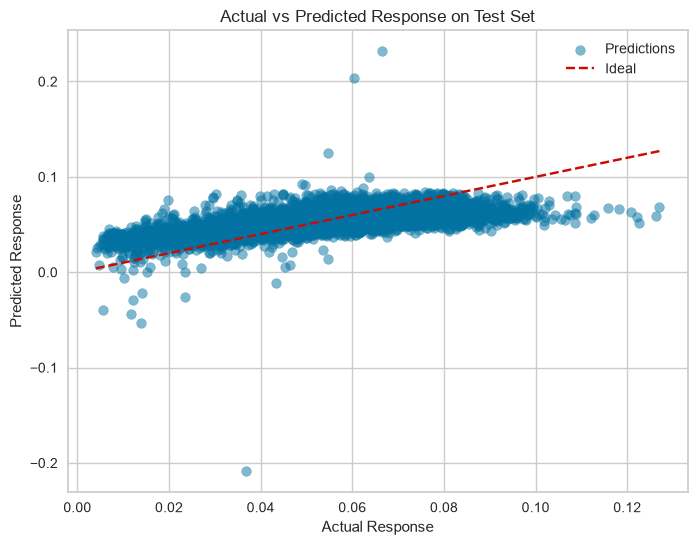

In [89]:
# Joel updated
# Predict on Test Set and Create Scatterplot
predictions = elastic_model.predict(X_test_pca)

plt.figure(figsize=(8,6))
plt.scatter(y_test, predictions, alpha=0.5, label="Predictions")
# Convert y_test to a Series using to_series() before using min/max.
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', label="Ideal")
plt.xlabel("Actual Response")
plt.ylabel("Predicted Response")
plt.title("Actual vs Predicted Response on Test Set")
plt.legend()
plt.show()

In [90]:
# MSE, RMSE, R², and Bootstrapped Confidence Intervals

mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)
print("Test Set Metrics:")
print(f"Mean Squared Error (MSE): {mse:.6f}")
print(f"R² Score: {r2:.3f}")

def bootstrap_metric(metric_func, y_true, y_pred, n_iterations=1000, random_state=2025):
    np.random.seed(random_state)
    metric_vals = []
    n = len(y_true)
    for _ in range(n_iterations):
        indices = np.random.randint(0, n, n)
        metric_val = metric_func(y_true[indices], y_pred[indices])
        metric_vals.append(metric_val)
    lower = np.percentile(metric_vals, 2.5)
    upper = np.percentile(metric_vals, 97.5)
    return lower, upper

mse_ci = bootstrap_metric(mean_squared_error, np.array(y_test), np.array(predictions))
r2_ci = bootstrap_metric(r2_score, np.array(y_test), np.array(predictions))

print("\nBootstrapped 95% Confidence Intervals:")
print(f"MSE: {mse_ci[0]:.6f} to {mse_ci[1]:.6f}")
print(f"R²: {r2_ci[0]:.3f} to {r2_ci[1]:.3f}")

Test Set Metrics:
Mean Squared Error (MSE): 0.000148
R² Score: 0.414

Bootstrapped 95% Confidence Intervals:
MSE: 0.000138 to 0.000161
R²: 0.366 to 0.454


C:\Users\musta\AppData\Local\Temp\ipykernel_45468\3827736997.py:12: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


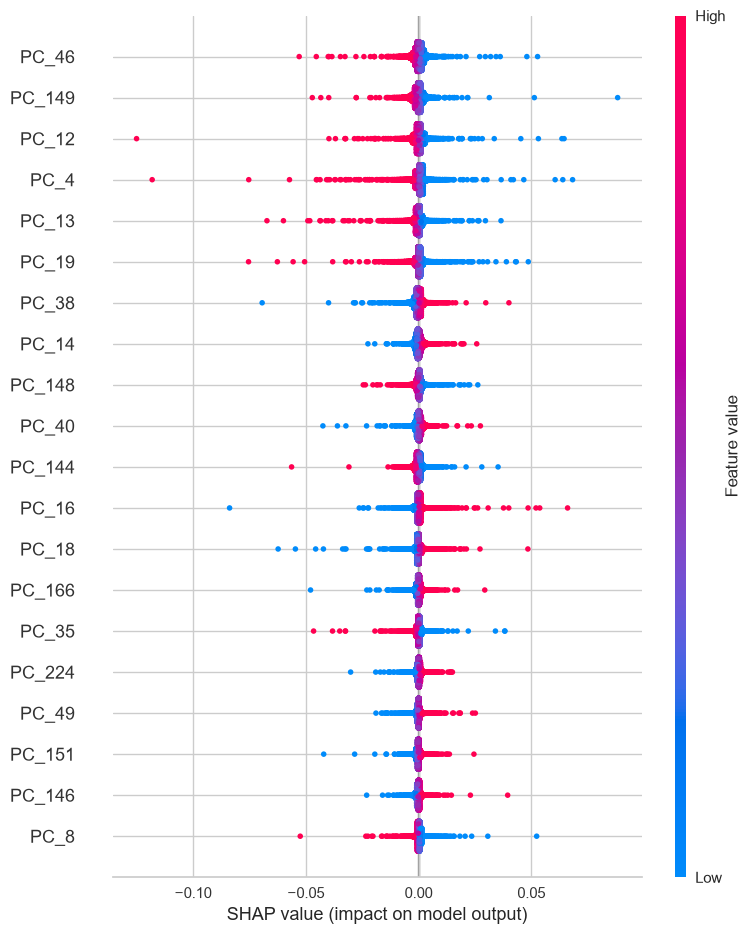

C:\Users\musta\AppData\Local\Temp\ipykernel_45468\3827736997.py:23: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


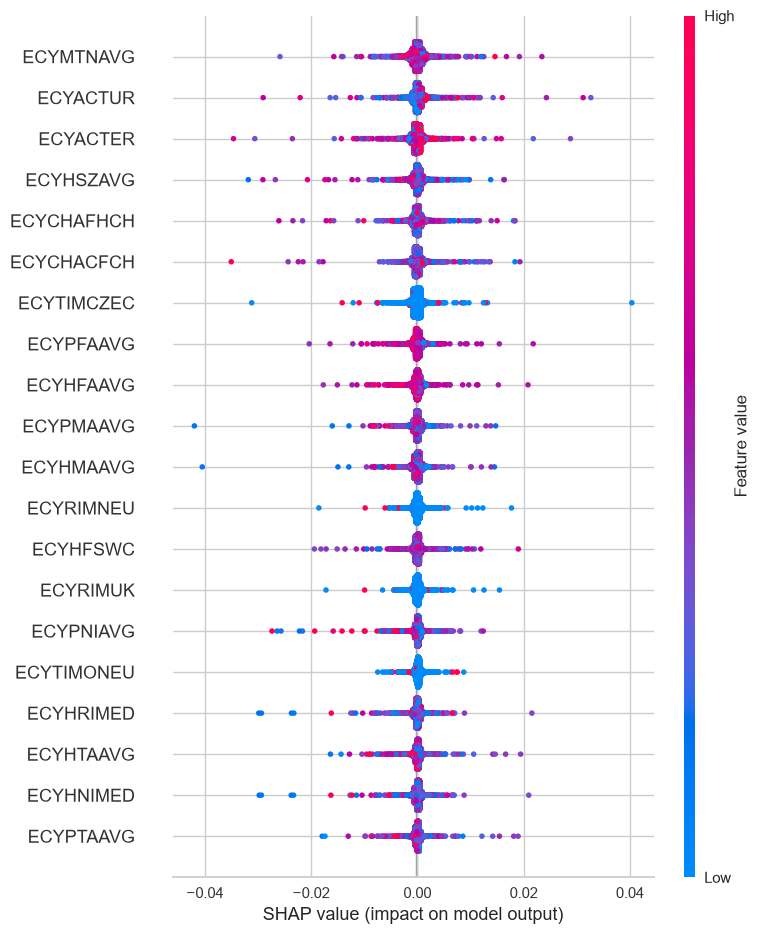

In [91]:
# Original feature names from Polars X_train DataFrame
original_feature_names = X_train.columns

# Build the explainer on the already‑fitted ElasticNet in PC‑space
masker    = shap.maskers.Independent(X_train_pca)
explainer = shap.LinearExplainer(elastic_model, masker)

# Compute SHAP values for test set (in PC‐space)
shap_pca = explainer.shap_values(X_test_pca)

# Bar summary of which PRINCIPAL COMPONENTS matter most
shap.summary_plot(
    shap_pca,
    X_test_pca,
    feature_names=[f"PC_{i+1}" for i in range(X_test_pca.shape[1])],
    plot_type="dot"
)

# Project those PC‑SHAP values back to ORIGINAL FEATURES:
shap_orig = shap_pca.dot(pca.components_)

# Bar summary of which ORIGINAL FEATURES matter most
shap.summary_plot(
    shap_orig,
    X_test_scaled,
    feature_names=original_feature_names,
    plot_type="dot"
)

Beginning of Meghan's Elastic Net code

In [92]:
# Already dropped above
# X_train = X_train.drop("CODE")
# X_test = X_test.drop("CODE")
# X_val =X_val.drop("CODE")

In [93]:
tracking_seed = 2025

In [94]:
l1_candidates = [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1]
alpha_candidates = np.logspace(-3, 1, 100)

EN_CV = ElasticNetCV(alphas=alpha_candidates,
                     l1_ratio=l1_candidates,
                     cv=5,
                     n_jobs=2,
                     random_state=tracking_seed,
                     max_iter=20000,
                     tol=1e-3,
                     verbose=2)

EN_CV_pipe = Pipeline(
    steps=[('scaler', StandardScaler()),
           ('EN_CV', EN_CV)]
)

EN_CV_pipe.fit(X_train, y_train)

[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.


Path: 000 out of 100
Path: 001 out of 100
Path: 002 out of 100
Path: 003 out of 100
Path: 004 out of 100
Path: 005 out of 100
Path: 006 out of 100
Path: 007 out of 100
Path: 008 out of 100
Path: 009 out of 100
Path: 010 out of 100
Path: 011 out of 100
Path: 012 out of 100
Path: 013 out of 100
Path: 014 out of 100
Path: 015 out of 100
Path: 016 out of 100
Path: 017 out of 100
Path: 018 out of 100
Path: 019 out of 100
Path: 020 out of 100
Path: 021 out of 100
Path: 022 out of 100
Path: 023 out of 100
Path: 024 out of 100
Path: 025 out of 100
Path: 026 out of 100
Path: 027 out of 100
Path: 028 out of 100
Path: 000 out of 100
Path: 029 out of 100
Path: 001 out of 100
Path: 030 out of 100
Path: 002 out of 100
Path: 031 out of 100
Path: 003 out of 100
Path: 032 out of 100
Path: 004 out of 100
Path: 033 out of 100
Path: 005 out of 100
Path: 034 out of 100
Path: 006 out of 100
Path: 035 out of 100
Path: 007 out of 100
Path: 036 out of 100
Path: 008 out of 100
Path: 037 out of 100
Path: 009 out

c:\Users\musta\AppData\Local\Python\pythoncore-3.11-64\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.807951e-02, tolerance: 1.081e-02
  model = cd_fast.enet_coordinate_descent_gram(


Path: 087 out of 100
Path: 099 out of 100
Path: 000 out of 100
Path: 001 out of 100
Path: 002 out of 100
Path: 003 out of 100
Path: 004 out of 100
Path: 005 out of 100
Path: 006 out of 100
Path: 007 out of 100
Path: 008 out of 100
Path: 009 out of 100
Path: 010 out of 100
Path: 011 out of 100
Path: 012 out of 100
Path: 013 out of 100
Path: 014 out of 100
Path: 015 out of 100
Path: 016 out of 100
Path: 017 out of 100
Path: 018 out of 100
Path: 019 out of 100
Path: 020 out of 100
Path: 021 out of 100
Path: 022 out of 100
Path: 023 out of 100
Path: 024 out of 100
Path: 025 out of 100
Path: 026 out of 100
Path: 027 out of 100
Path: 028 out of 100
Path: 029 out of 100
Path: 030 out of 100
Path: 031 out of 100
Path: 032 out of 100
Path: 033 out of 100
Path: 034 out of 100
Path: 035 out of 100
Path: 036 out of 100
Path: 037 out of 100
Path: 038 out of 100
Path: 039 out of 100
Path: 040 out of 100
Path: 041 out of 100
Path: 042 out of 100
Path: 043 out of 100
Path: 044 out of 100
Path: 045 out

c:\Users\musta\AppData\Local\Python\pythoncore-3.11-64\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.029747e-02, tolerance: 1.081e-02
  model = cd_fast.enet_coordinate_descent_gram(


Path: 088 out of 100
Path: 071 out of 100
Path: 072 out of 100
Path: 073 out of 100


c:\Users\musta\AppData\Local\Python\pythoncore-3.11-64\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.466490e-02, tolerance: 1.081e-02
  model = cd_fast.enet_coordinate_descent_gram(


Path: 089 out of 100
Path: 074 out of 100


c:\Users\musta\AppData\Local\Python\pythoncore-3.11-64\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.165712e-02, tolerance: 1.081e-02
  model = cd_fast.enet_coordinate_descent_gram(


Path: 090 out of 100
Path: 075 out of 100
Path: 091 out of 100
Path: 092 out of 100


c:\Users\musta\AppData\Local\Python\pythoncore-3.11-64\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.483352e-02, tolerance: 1.080e-02
  model = cd_fast.enet_coordinate_descent_gram(


Path: 076 out of 100
Path: 077 out of 100


c:\Users\musta\AppData\Local\Python\pythoncore-3.11-64\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.391284e-02, tolerance: 1.081e-02
  model = cd_fast.enet_coordinate_descent_gram(


Path: 093 out of 100
Path: 078 out of 100
Path: 094 out of 100
Path: 079 out of 100
Path: 095 out of 100
Path: 080 out of 100
Path: 081 out of 100
Path: 096 out of 100
Path: 082 out of 100
Path: 083 out of 100
Path: 084 out of 100
Path: 085 out of 100


c:\Users\musta\AppData\Local\Python\pythoncore-3.11-64\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.384822e-02, tolerance: 1.081e-02
  model = cd_fast.enet_coordinate_descent_gram(


Path: 097 out of 100
Path: 086 out of 100
Path: 098 out of 100
Path: 087 out of 100
Path: 088 out of 100
Path: 099 out of 100
Path: 089 out of 100
Path: 000 out of 100
Path: 001 out of 100
Path: 002 out of 100
Path: 003 out of 100
Path: 004 out of 100
Path: 005 out of 100
Path: 006 out of 100
Path: 007 out of 100
Path: 008 out of 100
Path: 009 out of 100
Path: 010 out of 100
Path: 011 out of 100
Path: 012 out of 100
Path: 013 out of 100
Path: 014 out of 100
Path: 015 out of 100
Path: 016 out of 100
Path: 017 out of 100
Path: 018 out of 100
Path: 019 out of 100
Path: 020 out of 100
Path: 021 out of 100
Path: 022 out of 100
Path: 023 out of 100
Path: 024 out of 100
Path: 025 out of 100
Path: 026 out of 100
Path: 027 out of 100
Path: 028 out of 100
Path: 029 out of 100
Path: 030 out of 100
Path: 031 out of 100
Path: 032 out of 100
Path: 033 out of 100
Path: 034 out of 100
Path: 035 out of 100
Path: 036 out of 100
Path: 037 out of 100
Path: 038 out of 100
Path: 039 out of 100
Path: 040 out

c:\Users\musta\AppData\Local\Python\pythoncore-3.11-64\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.842385e-02, tolerance: 1.071e-02
  model = cd_fast.enet_coordinate_descent_gram(


Path: 082 out of 100
Path: 083 out of 100
Path: 084 out of 100
Path: 083 out of 100
Path: 085 out of 100
Path: 086 out of 100
Path: 087 out of 100


c:\Users\musta\AppData\Local\Python\pythoncore-3.11-64\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.148580e-02, tolerance: 1.071e-02
  model = cd_fast.enet_coordinate_descent_gram(


Path: 084 out of 100
Path: 088 out of 100
Path: 089 out of 100
Path: 090 out of 100


c:\Users\musta\AppData\Local\Python\pythoncore-3.11-64\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.783379e-02, tolerance: 1.071e-02
  model = cd_fast.enet_coordinate_descent_gram(


Path: 085 out of 100
Path: 091 out of 100
Path: 092 out of 100


c:\Users\musta\AppData\Local\Python\pythoncore-3.11-64\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.585943e-02, tolerance: 1.071e-02
  model = cd_fast.enet_coordinate_descent_gram(


Path: 086 out of 100
Path: 093 out of 100
Path: 094 out of 100


c:\Users\musta\AppData\Local\Python\pythoncore-3.11-64\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.615281e-02, tolerance: 1.071e-02
  model = cd_fast.enet_coordinate_descent_gram(


Path: 087 out of 100
Path: 088 out of 100
Path: 095 out of 100
Path: 089 out of 100
Path: 096 out of 100
Path: 097 out of 100
Path: 090 out of 100
Path: 098 out of 100


c:\Users\musta\AppData\Local\Python\pythoncore-3.11-64\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.089352e-02, tolerance: 1.071e-02
  model = cd_fast.enet_coordinate_descent_gram(


Path: 091 out of 100
Path: 099 out of 100
Path: 000 out of 100
Path: 001 out of 100
Path: 002 out of 100
Path: 003 out of 100
Path: 004 out of 100
Path: 005 out of 100
Path: 006 out of 100
Path: 007 out of 100
Path: 008 out of 100
Path: 009 out of 100
Path: 010 out of 100
Path: 011 out of 100
Path: 012 out of 100
Path: 013 out of 100
Path: 014 out of 100
Path: 015 out of 100
Path: 016 out of 100
Path: 017 out of 100
Path: 018 out of 100
Path: 019 out of 100
Path: 020 out of 100
Path: 021 out of 100
Path: 022 out of 100
Path: 023 out of 100
Path: 024 out of 100
Path: 025 out of 100
Path: 026 out of 100
Path: 027 out of 100
Path: 028 out of 100
Path: 029 out of 100
Path: 030 out of 100
Path: 031 out of 100
Path: 032 out of 100
Path: 033 out of 100
Path: 034 out of 100
Path: 035 out of 100
Path: 036 out of 100
Path: 037 out of 100
Path: 038 out of 100
Path: 039 out of 100
Path: 040 out of 100
Path: 041 out of 100
Path: 042 out of 100
Path: 043 out of 100
Path: 044 out of 100
Path: 045 out

c:\Users\musta\AppData\Local\Python\pythoncore-3.11-64\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.607517e-02, tolerance: 1.071e-02
  model = cd_fast.enet_coordinate_descent_gram(


Path: 092 out of 100
Path: 086 out of 100
Path: 087 out of 100
Path: 088 out of 100
Path: 089 out of 100
Path: 090 out of 100
Path: 091 out of 100
Path: 092 out of 100
Path: 093 out of 100
Path: 093 out of 100
Path: 094 out of 100
Path: 095 out of 100
Path: 096 out of 100
Path: 097 out of 100


c:\Users\musta\AppData\Local\Python\pythoncore-3.11-64\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.949475e-02, tolerance: 1.071e-02
  model = cd_fast.enet_coordinate_descent_gram(


Path: 094 out of 100
Path: 098 out of 100
Path: 099 out of 100
Path: 000 out of 100
Path: 001 out of 100
Path: 002 out of 100
Path: 003 out of 100
Path: 004 out of 100
Path: 005 out of 100
Path: 006 out of 100
Path: 007 out of 100
Path: 008 out of 100
Path: 009 out of 100
Path: 010 out of 100
Path: 011 out of 100
Path: 012 out of 100
Path: 013 out of 100
Path: 014 out of 100
Path: 015 out of 100
Path: 016 out of 100
Path: 017 out of 100
Path: 018 out of 100
Path: 019 out of 100
Path: 020 out of 100
Path: 021 out of 100
Path: 022 out of 100
Path: 023 out of 100
Path: 024 out of 100
Path: 025 out of 100
Path: 026 out of 100
Path: 027 out of 100
Path: 028 out of 100
Path: 029 out of 100
Path: 030 out of 100
Path: 031 out of 100
Path: 032 out of 100
Path: 033 out of 100
Path: 034 out of 100
Path: 035 out of 100
Path: 036 out of 100
Path: 037 out of 100
Path: 038 out of 100
Path: 039 out of 100
Path: 040 out of 100
Path: 041 out of 100
Path: 042 out of 100
Path: 043 out of 100
Path: 044 out

c:\Users\musta\AppData\Local\Python\pythoncore-3.11-64\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.309260e-02, tolerance: 1.071e-02
  model = cd_fast.enet_coordinate_descent_gram(


Path: 095 out of 100
Path: 076 out of 100
Path: 077 out of 100
Path: 078 out of 100
Path: 079 out of 100
Path: 080 out of 100
Path: 081 out of 100
Path: 082 out of 100
Path: 083 out of 100
Path: 084 out of 100
Path: 085 out of 100
Path: 086 out of 100
Path: 087 out of 100
Path: 088 out of 100
Path: 089 out of 100
Path: 090 out of 100
Path: 091 out of 100
Path: 092 out of 100
Path: 093 out of 100
Path: 096 out of 100


c:\Users\musta\AppData\Local\Python\pythoncore-3.11-64\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.963148e-02, tolerance: 1.071e-02
  model = cd_fast.enet_coordinate_descent_gram(


Path: 094 out of 100
Path: 095 out of 100
Path: 096 out of 100
Path: 097 out of 100
Path: 098 out of 100


c:\Users\musta\AppData\Local\Python\pythoncore-3.11-64\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.104433e-02, tolerance: 1.071e-02
  model = cd_fast.enet_coordinate_descent_gram(


Path: 097 out of 100
Path: 099 out of 100
Path: 000 out of 100
Path: 001 out of 100
Path: 002 out of 100
Path: 003 out of 100
Path: 004 out of 100
Path: 005 out of 100
Path: 006 out of 100
Path: 007 out of 100
Path: 008 out of 100
Path: 009 out of 100
Path: 010 out of 100
Path: 011 out of 100
Path: 012 out of 100
Path: 013 out of 100
Path: 014 out of 100
Path: 015 out of 100
Path: 016 out of 100
Path: 017 out of 100
Path: 018 out of 100
Path: 019 out of 100
Path: 020 out of 100
Path: 021 out of 100
Path: 022 out of 100
Path: 023 out of 100
Path: 024 out of 100
Path: 025 out of 100
Path: 026 out of 100
Path: 027 out of 100
Path: 028 out of 100
Path: 029 out of 100
Path: 030 out of 100
Path: 031 out of 100
Path: 032 out of 100
Path: 033 out of 100
Path: 034 out of 100
Path: 035 out of 100
Path: 036 out of 100
Path: 037 out of 100
Path: 038 out of 100
Path: 039 out of 100
Path: 040 out of 100
Path: 041 out of 100
Path: 042 out of 100
Path: 043 out of 100
Path: 044 out of 100
Path: 045 out

c:\Users\musta\AppData\Local\Python\pythoncore-3.11-64\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.101719e-02, tolerance: 1.071e-02
  model = cd_fast.enet_coordinate_descent_gram(


Path: 098 out of 100
Path: 084 out of 100
Path: 085 out of 100
Path: 086 out of 100
Path: 087 out of 100
Path: 088 out of 100
Path: 089 out of 100
Path: 099 out of 100
Path: 090 out of 100
Path: 091 out of 100
Path: 000 out of 100
Path: 001 out of 100
Path: 002 out of 100
Path: 003 out of 100
Path: 004 out of 100
Path: 005 out of 100
Path: 006 out of 100
Path: 007 out of 100
Path: 008 out of 100
Path: 009 out of 100
Path: 010 out of 100
Path: 011 out of 100
Path: 012 out of 100
Path: 013 out of 100
Path: 014 out of 100
Path: 015 out of 100
Path: 016 out of 100
Path: 017 out of 100
Path: 018 out of 100
Path: 019 out of 100
Path: 020 out of 100
Path: 021 out of 100
Path: 022 out of 100
Path: 023 out of 100
Path: 024 out of 100
Path: 025 out of 100
Path: 026 out of 100
Path: 027 out of 100
Path: 028 out of 100
Path: 029 out of 100
Path: 030 out of 100
Path: 031 out of 100
Path: 032 out of 100
Path: 033 out of 100
Path: 034 out of 100
Path: 035 out of 100
Path: 036 out of 100
Path: 037 out

[Parallel(n_jobs=2)]: Done  35 out of  35 | elapsed: 14.5min finished
c:\Users\musta\AppData\Local\Python\pythoncore-3.11-64\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:842: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.279804e-02, tolerance: 1.347e-02
  model = cd_fast.enet_coordinate_descent(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('EN_CV', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](967,)","['HSBASHHD','HSAGDISPIN','HSAGDISCIN',...,'ECYNCANCIT','ECYNCA_U18', 'ECYNCA_18P']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,967
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value


In [95]:
# Access the fitted ElasticNetCV step
fitted_en_cv = EN_CV_pipe.named_steps['EN_CV']
best_alpha = fitted_en_cv.alpha_
best_l1_ratio = fitted_en_cv.l1_ratio_
coefs = fitted_en_cv.coef_
intercept = fitted_en_cv.intercept_

In [96]:
# Get the best alpha (as you already have)
best_alpha = 0.0027825594022071257

# Get the best l1_ratio
best_l1_ratio = 0.1

In [97]:
elasNet_opt = ElasticNet(alpha = best_alpha,
                         l1_ratio = best_l1_ratio,
                         max_iter = 20000,
                         random_state = tracking_seed)

elasNet_pipe_opt = Pipeline([('scaler', StandardScaler()),
                             ('elasNet_opt', elasNet_opt)])

elasNet_pipe_opt.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('elasNet_opt', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](967,)","['HSBASHHD','HSAGDISPIN','HSAGDISCIN',...,'ECYNCANCIT','ECYNCA_U18', 'ECYNCA_18P']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,967
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value


In [98]:
# # Define the ElasticNet Regression
# elastic_Net = ElasticNet(random_state=2025)

# # Define cross-valdiation object using 3-fold CV
# cv_object = KFold(n_splits = 3,
#                   shuffle = True,
#                   random_state=2025)

# # Define the parameter grid for alpha (learning rate) and l1 ratio
# param_grid_elas = dict({'alpha': [0.008, 0.01, 0.015, 0.1],
#                         'l1_ratio': [0.003, 0.008, 0.01, 0.05],
#                         'max_iter': [8000, 10000, 12000]})

# # Define the Grid Search object that will help us determine the best hyperparameters
# # for our model
# grid_elas = GridSearchCV(elastic_Net,
#                           param_grid_elas,
#                           cv = cv_object,
#                           scoring = ['r2', 'neg_mean_squared_error'],
#                           refit = 'r2',
#                           n_jobs = -1,
#                           verbose = 2)

# ElasNet_pipe = Pipeline(
#     steps=[('scaler', StandardScaler()),
#            ('elastic_net', grid_elas)]
# )

# ElasNet_pipe.fit(X_train, Y_train)
# ElasNet_pipe.named_steps['elastic_net'].best_params_

Create an Elastic Net model with the optimal parameters as determined by the GridSearchCV and train it.

In [99]:
# opt_alpha = 0.015
# opt_l1_ratio = 0.01
# opt_max_iter = 10000

# elasNet_opt = ElasticNet(alpha = opt_alpha,
#                          l1_ratio = opt_l1_ratio,
#                          max_iter = opt_max_iter,
#                          random_state = 2025)
# elasNet_pipe_opt = Pipeline([('scaler', StandardScaler()),
#                              ('elasNet_opt', elasNet_opt)])

# elasNet_pipe_opt.fit(X_train, y_train)

Use the optimized elastic net model to make predictions on Y_val to see how our model is looking with our new parameters.

In [100]:
Y_val_pred = elasNet_pipe_opt.predict(X_val)
mse_val = mean_squared_error(y_val, Y_val_pred)
r2_val = r2_score(y_val, Y_val_pred)

print(f"The mean squared error on the validation set is {mse_val}")
print(f"The R^2 score on the validation set is {r2_val}")

The mean squared error on the validation set is 0.00014698287554160014
The R^2 score on the validation set is 0.40862405341496544


Repeat above process on the test set.

In [101]:
Y_test_pred = elasNet_pipe_opt.predict(X_test)
mse_test = mean_squared_error(y_test, Y_test_pred)
r2_test = r2_score(y_test, Y_test_pred)

print(f"The mean squared error on the test set is {mse_test}")
print(f"The R^2 score on the test set is {r2_test}")

The mean squared error on the test set is 0.00015067815807425788
The R^2 score on the test set is 0.40538660413050787


Plot the actual vs predicted values for X_test.

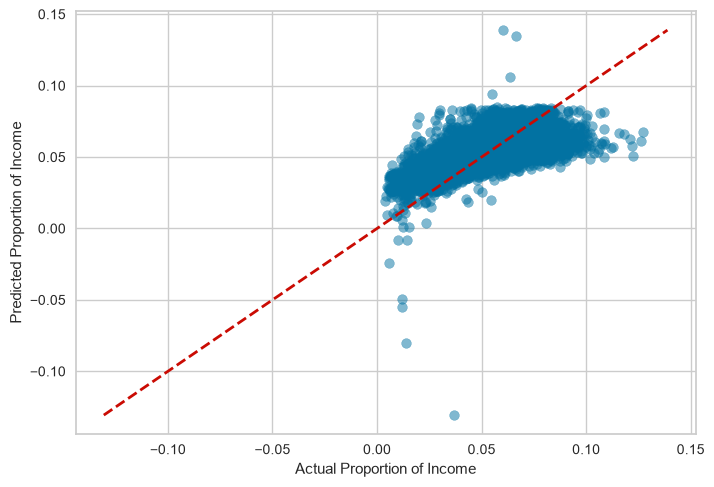

In [102]:
plt.scatter(y_test, Y_test_pred, alpha = 0.5)
plt.xlabel("Actual Proportion of Income")
plt.ylabel("Predicted Proportion of Income")
min_val = min(y_test.min(), Y_test_pred.min())
max_val = max(y_test.max(), Y_test_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Ideal (y=x)')
plt.show()

In [103]:
# Calculating residuals (validation data)
y_test_pred = elasNet_pipe_opt.predict(X_test)
residuals = y_test - y_test_pred

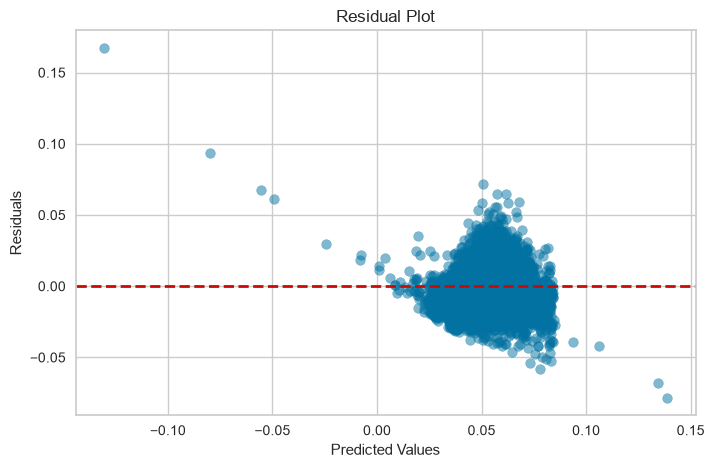

In [104]:
# Residual plot (validation data)

plt.figure(figsize=(8, 5))
plt.scatter(y_test_pred, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--', linewidth=2)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.grid(True)
plt.show()

In [105]:
# Make predictions on the test set using the best model
y_test_pred = elasNet_pipe_opt.predict(X_test)

# Evaluate the model on the test set
mse = mean_squared_error(y_test, y_test_pred)
r2 = r2_score(y_test, y_test_pred)

print(f"  Mean Squared Error (MSE): {mse:.4f}")
print(f"  R-squared (R2 Score):   {r2:.4f}")

# Bootstrap confidence intervals for MSE and R^2

# Number of bootstrap iterations
n_bootstrap = 1000

# Lists to store the bootstrapped values
mse_bootstrap = []
r2_bootstrap = []

# For reproducibility
np.random.seed(2025)

# Do bootstrap resampling on the test set
for i in range(n_bootstrap):
    # Resampling w/ repl
    sample_indices = np.random.choice(len(y_test), size=len(y_test), replace=True)

    # Bootstrap samples for y_test and the predictions
    y_test_boot = y_test[sample_indices]
    y_pred_boot = y_test_pred[sample_indices]

    # Compute and store the performance scores for the current bootstrap sample
    mse_bootstrap.append(mean_squared_error(y_test_boot, y_pred_boot))
    r2_bootstrap.append(r2_score(y_test_boot, y_pred_boot))

# Convert the results to numpy arrays
mse_bootstrap = np.array(mse_bootstrap)
r2_bootstrap = np.array(r2_bootstrap)

# Calculate the 2.5th and 97.5th percentiles for the bootstrap distributions
mse_ci_lower, mse_ci_upper = np.percentile(mse_bootstrap, [2.5, 97.5])
r2_ci_lower, r2_ci_upper = np.percentile(r2_bootstrap, [2.5, 97.5])

# Report the bootstrap confidence intervals
print("\nBootstrap 95% Confidence Intervals:")
print(f"Mean Squared Error (MSE): [{mse_ci_lower:.4f}, {mse_ci_upper:.4f}]")
print(f"R-squared (R2 Score): [{r2_ci_lower:.4f}, {r2_ci_upper:.4f}]")

  Mean Squared Error (MSE): 0.0002
  R-squared (R2 Score):   0.4054

Bootstrap 95% Confidence Intervals:
Mean Squared Error (MSE): [0.0001, 0.0002]
R-squared (R2 Score): [0.3812, 0.4267]


Extract Elastic Net coefficients

In [106]:
# Extract coefficients and intercept
coefficients = elasNet_pipe_opt.named_steps["elasNet_opt"].coef_
intercept = elasNet_pipe_opt.named_steps["elasNet_opt"].intercept_

# Create Series with feature names
coef_series = pd.Series(coefficients, index=X_train_pl.to_pandas().columns)

# Filter non-zero coefficients
non_zero_coefs = coef_series[coef_series != 0]

# Sort by absolute value (strongest effects first)
sorted_coefs_abs = non_zero_coefs.reindex(non_zero_coefs.abs().sort_values(ascending=False).index)

# print("Intercept:", intercept)
# print("Non-zero Coefficients:\n", non_zero_coefs)

Looking at the most important variables

In [107]:
(
    sorted_coefs_abs.reset_index().rename(columns = {"index" : "Variable"})
    .merge(metadata_df, on = "Variable", how = "left")
    .head(20)
)

,Variable,0,Description
0,ECYMTNAVG,-0.008058,Average Maintainer Age
1,ECYINDPUBL,0.002416,91 Public Administration
2,ECYHRIAVG,-0.001656,Average Household Income (Constant Year 2020 $)
3,ECYHRI300P,-0.001383,"Household Income $300,000 Or Over (Constant Ye..."
4,ECYHNIAVG,-0.001337,Average Household Income (Current Year $)
5,ECYHSZAVG,-0.000811,Average Number Of Persons In Private Households
6,ECYHRI_020,-0.000676,"Household Income $0 To $19,999 (Constant Year ..."
7,HSSH054,-0.000669,Additional amounts paid to the landlord
8,ECYHNI300P,-0.000665,"Household Income $300,000 Or Over (Current Yea..."
9,ECYPTAAVG,-0.000595,Average Age Of Total Population


## Define XGBoost Pipeline and Grid Search

Initialize the XGBoost regressor

In [ ]:
XGB_regressor = XGBRegressor(
    random_state=2025, # Seed for reproducibility
    n_jobs=1,          # One thread per model; the search runs models in parallel (avoids 64 threads on 8 cores)
    tree_method="hist"
)

Set up a basic pipeline for XGBoost

In [109]:
# Define a basic pipeline; just contains the regressor right now
xgb_pipeline = Pipeline(steps=[('regressor', XGB_regressor)])

Set up the hyperparameter search grid

In [110]:
param_grid_xgb = {
    'regressor__n_estimators': [50, 100, 200, 300, 400],
    'regressor__learning_rate': [0.025, 0.05, 0.1, 0.15, 0.2],
    'regressor__max_depth': [1, 3, 5, 7, 9],
    # 'regressor__objective' : ['reg:squarederror', 'r2'],
    # 'regressor__subsample': [0.7, 0.9, 1.0],
    # 'regressor__colsample_bytree': [0.7, 0.9, 1.0],
    # 'regressor__gamma': [0, 1],
    # 'regressor__reg_alpha': [0, 1],
    # 'regressor__reg_lambda': [0, 1]
}

Set up the cross-validation parameters

In [111]:
# Define cross-validation scheme
cv_object_xgb = KFold(n_splits = 5, shuffle = True, random_state = 2025)

Initialize the grid search object

In [ ]:
# Randomized search: 20 of the 125 combinations x 3 folds = 60 fits (was 625)
from sklearn.model_selection import RandomizedSearchCV

grid_search_xgb = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=param_grid_xgb,
    n_iter=20,
    scoring='neg_mean_squared_error', # Or 'r2'
    cv=KFold(n_splits=3, shuffle=True, random_state=2025),
    n_jobs=-1,          # Use all cores for CV folds
    verbose=1,          # Worker logs go to the Jupyter terminal, not the notebook
    random_state=2025,
    refit=False         # Cell 179 retrains the final model on all cores; refit here would be single-threaded
)

Run the grid search

In [ ]:
# Run GridSearchCV
grid_search_xgb.fit(X_train, y_train)

## Save Model Results
- Export GridSearchCV object for future use.

In [ ]:
import pickle

# with open("D:\\Downloads\\2025-04-19_gridsearchcv_results_0009.pkl", 'wb') as f:
#     pickle.dump(grid_search_xgb, f)

with open(r"C:\Users\musta\Documents\Projects\household data dashboard\Data\2025-04-20_gridsearchcv_results_0011.pkl", 'wb') as f:
    pickle.dump(grid_search_xgb, f)

Load the GridSearchCV result from a pickle file instead of re-running it

In [ ]:
# import pickle

# # Open the pickle file in binary read mode
# with open("D:\\Downloads\\2025-04-19_gridsearchcv_results_0009.pkl", 'rb') as file:
#     grid_search_xgb = pickle.load(file)

Save the best hyperparameters that were found

In [ ]:
# Save the best prarameters
best_params = grid_search_xgb.best_params_

NameError: name 'grid_search_xgb' is not defined

Show the best hyperparameters found

In [ ]:
# Show best params found by GridSearchCV
print("\nBest parameters found by GridSearchCV:")
print(best_params)


Best parameters found by GridSearchCV:


NameError: name 'best_params' is not defined

### Leakage fix (v2)
Eight columns can rebuild the target through accounting identities, e.g. `HSEP001S = HSTE001 − HSTX001 − HSTC001 − HSMG001S`
(exact on every row) and `HSHNIAGG ≈ HSAGDISPIN + HSTX001 + HSEP001S`. They're dropped before training the final model.
Leakage check with the same split, seed and hyperparameters: R² 0.863 → 0.861, MAE 0.00439 → 0.00444.

In [ ]:
# Columns that can mechanically rebuild the target (numerator identity + income-derived denominator proxies)
LEAKY_COLS = ["HSTE001", "HSTX001", "HSTC001", "HSMG001S", "HSTT001", "HSTE001ZBS", "HSAGDISPIN", "HSAGDISCIN"]

X_train = X_train.drop(columns=LEAKY_COLS, errors="ignore")
X_test = X_test.drop(columns=LEAKY_COLS, errors="ignore")
print("Features after leakage fix:", X_train.shape[1])

## Train Final Model

In [ ]:
# Initialize a new XGBoost regressor using the best hyperparameters we found
final_xgb_model = XGBRegressor(
    n_estimators=best_params['regressor__n_estimators'],
    learning_rate=best_params['regressor__learning_rate'],
    max_depth=best_params['regressor__max_depth'],
    random_state=2025,
    n_jobs=-1,
    verbosity=2
)

# Train the final model
final_xgb_model.fit(X_train, y_train)

Calculate residuals on the test set

In [ ]:
y_test_pred = final_xgb_model.predict(X_test)
residuals = y_test - y_test_pred

Create a residual plot

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test_pred, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--', linewidth=2)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.grid(True)
plt.show()

NameError: name 'plt' is not defined

## Evaluate Final Model on Test Set

In [ ]:
# Make predictions on the test set using the best model
y_pred_test = final_xgb_model.predict(X_test)

NameError: name 'final_xgb_model' is not defined

In [ ]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

# Evaluate the model using regression metrics
mse = mean_squared_error(y_test, y_pred_test)
r2 = r2_score(y_test, y_pred_test)

print(f"\nModel Evaluation on Test Set:")
print(f"  Mean Squared Error (MSE): {mse:.4f}")
print(f"  R-squared (R2 Score):   {r2:.4f}")

NameError: name 'y_test' is not defined

## Visualize Predictions

In [ ]:
# Scatter plot of Actual vs Predicted values
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred_test, alpha=0.5, edgecolor='k', s=50)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], '--r', linewidth=2, label='Theoretical Perfect Fit (y=x)') # Diagonal line for reference
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs. Predicted Target (XGBoost)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

NameError: name 'plt' is not defined

## Confidence Intervals via Bootstrapping
- Generate 95% confidence intervals for MSE and R².

In [ ]:
# Make predictions on the test set using the best model
y_pred_test = final_xgb_model.predict(X_test)

# Evaluate the model on the test set
mse = mean_squared_error(y_test, y_pred_test)
r2 = r2_score(y_test, y_pred_test)

print(f"  Mean Squared Error (MSE): {mse:.4f}")
print(f"  R-squared (R2 Score):   {r2:.4f}")

# Bootstrap confidence intervals for MSE and R^2

# Number of bootstrap iterations
n_bootstrap = 1000

# Lists to store the bootstrapped values
mse_bootstrap = []
r2_bootstrap = []

# For reproducibility
np.random.seed(2025)

# Do bootstrap resampling on the test set
for i in range(n_bootstrap):
    # Resampling w/ repl
    sample_indices = np.random.choice(len(y_test), size=len(y_test), replace=True)

    # Bootstrap samples for y_test and the predictions
    y_test_boot = y_test[sample_indices]
    y_pred_boot = y_pred_test[sample_indices]

    # Compute and store the performance scores for the current bootstrap sample
    mse_bootstrap.append(mean_squared_error(y_test_boot, y_pred_boot))
    r2_bootstrap.append(r2_score(y_test_boot, y_pred_boot))

# Convert the results to numpy arrays
mse_bootstrap = np.array(mse_bootstrap)
r2_bootstrap = np.array(r2_bootstrap)

# Calculate the 2.5th and 97.5th percentiles for the bootstrap distributions
mse_ci_lower, mse_ci_upper = np.percentile(mse_bootstrap, [2.5, 97.5])
r2_ci_lower, r2_ci_upper = np.percentile(r2_bootstrap, [2.5, 97.5])

# Report the bootstrap confidence intervals
print("\nBootstrap 95% Confidence Intervals:")
print(f"Mean Squared Error (MSE): [{mse_ci_lower:.4f}, {mse_ci_upper:.4f}]")
print(f"R-squared (R2 Score): [{r2_ci_lower:.4f}, {r2_ci_upper:.4f}]")


NameError: name 'final_xgb_model' is not defined

# Model Interpretability with SHAP

## Generate SHAP Values

In [ ]:
# Create a SHAP explainer for the XGBoost model
explainer = shap.TreeExplainer(final_xgb_model)

# Compute SHAP values for the test set
shap_values = explainer.shap_values(X_test)

## SHAP Summary Plot

In [ ]:
# Display a summary plot of feature importance
shap.summary_plot(shap_values, X_test)

NameError: name 'shap' is not defined

## Enhanced SHAP Summary with Feature Descriptions

In [ ]:
# Make sure columns are named correctly
metadata_df.columns = ['Variable', 'Description']

# Create a dict for mapping variable names to their descriptions
var_to_desc = dict(zip(metadata_df['Variable'], metadata_df['Description']))

# Rename columns in X_test using the dictionary
# If a variable isn't in metadata, just use the original name
X_test_renamed = X_test.rename(columns=lambda col: var_to_desc.get(col, col))

# print(X_test_renamed.columns.tolist())

shap.summary_plot(shap_values, X_test_renamed, max_display=30)

NameError: name 'metadata_df' is not defined

## Rank Features by SHAP Contribution

In [ ]:
# # Calculate mean absolute SHAP values per feature
# mean_abs_shap = np.abs(shap_values).mean(axis=0)

# shap_importance_df = pd.DataFrame({
#     'Description': X_test_renamed.columns,
#     'Mean_Absolute_SHAP': mean_abs_shap
# }).sort_values(by='Mean_Absolute_SHAP', ascending=False)

# top_n = 30
# shap_top = shap_importance_df.head(top_n)
# print(shap_top)

# Mean SHAP values (not absolute)
mean_shap = shap_values.mean(axis=0)

# Mean absolute SHAP values
mean_abs_shap = np.abs(shap_values).mean(axis=0)

# Create a DataFrame to hold the results
shap_importance_df = pd.DataFrame({
    'Description': X_test_renamed.columns,
    'Mean_SHAP': mean_shap,
    'Mean_Absolute_SHAP': mean_abs_shap
})

# Sort for top absolute importance (regardless of direction)
top_30_abs = shap_importance_df.sort_values(by='Mean_Absolute_SHAP', ascending=False).head(30)

# Sort for top positive contribution
top_20_pos = shap_importance_df.sort_values(by='Mean_SHAP', ascending=False).head(20)

# Sort for top negative contribution
top_20_neg = shap_importance_df.sort_values(by='Mean_SHAP', ascending=True).head(20)

# Print results
print("\nTop 30 Most Important Features (by |mean SHAP|):")
print(top_30_abs)

print("\nTop 20 Positive SHAP Contributors:")
print(top_20_pos)

print("\nTop 20 Negative SHAP Contributors:")
print(top_20_neg)


NameError: name 'shap_values' is not defined

## Dependence Plot for a chosen feature

In [ ]:
# Show a dependence plot for top feature
feature_name = 'ECYMTNAVG'
shap.dependence_plot(feature_name, shap_values, X_test)

In [ ]:
# Show a dependence plot for 2nd top feature
feature_name = 'ECYHNI200P'
shap.dependence_plot(feature_name, shap_values, X_test)

NameError: name 'shap' is not defined

In [ ]:
# Show a dependence plot for 3rd top feature
feature_name = 'ECYINDPUBL'
shap.dependence_plot(feature_name, shap_values, X_test)

NameError: name 'shap' is not defined

In [ ]:
# Show a dependence plot for 4th top feature
feature_name = 'ECYMTN6574'
shap.dependence_plot(feature_name, shap_values, X_test)

NameError: name 'shap' is not defined

In [ ]:
# Show a dependence plot for 5th top feature
feature_name = 'ECYMTN7584'
shap.dependence_plot(feature_name, shap_values, X_test)

NameError: name 'shap' is not defined

# EXPORT CLEANED CODE

**Superseded by the v2 exports at the end of the notebook.** This cell is commented out so re-running the
notebook can't overwrite the original files in `powerbi_exports/` with results from the leak-free model.

In [ ]:

# import os

# OUTPUT_DIR = r"C:\Users\musta\Documents\Projects\household data dashboard\Data\powerbi_exports" + os.sep
# os.makedirs(OUTPUT_DIR, exist_ok=True)


# # =====================================================================
# # EXPORT 1 — Cleaned dataset
# # Run any time after: `merged_data = household_data.join(demo_data, ...)`
# # =====================================================================

# merged_data.to_pandas().to_csv(OUTPUT_DIR + "cleaned_dataset.csv", index=False)
# print("[1/4] cleaned_dataset.csv exported:", merged_data.shape)


# # =====================================================================
# # EXPORT 2 — Model predictions + residuals
# # Run any time after: `final_xgb_model.fit(X_train, y_train)`
# #
# # test_df still has "CODE" at this point (only the derived df_test_xgb
# # had it dropped), and no row-reordering happens between test_df and
# # X_test/y_test, so this join is safe as-is.
# # =====================================================================

# y_pred_test = final_xgb_model.predict(X_test)

# predictions_export = pd.DataFrame({
#     "CODE": test_df["CODE"].to_pandas(),
#     "actual_insurance_pension_ratio": y_test,
#     "predicted_insurance_pension_ratio": y_pred_test,
# })
# predictions_export["residual"] = (
#     predictions_export["actual_insurance_pension_ratio"]
#     - predictions_export["predicted_insurance_pension_ratio"]
# )
# predictions_export["abs_error"] = predictions_export["residual"].abs()

# predictions_export.to_csv(OUTPUT_DIR + "model_predictions.csv", index=False)
# print("[2/4] model_predictions.csv exported:", predictions_export.shape)


# # =====================================================================
# # EXPORT 3 — SHAP feature importance
# # Run any time after your existing `shap_importance_df` is built
# # (the "Rank Features by SHAP Contribution" section).
# #
# # You've already computed exactly what Power BI needs — this just
# # saves it.
# # =====================================================================

# shap_importance_df.sort_values(
#     "Mean_Absolute_SHAP", ascending=False
# ).to_csv(OUTPUT_DIR + "shap_importance.csv", index=False)
# print("[3/4] shap_importance.csv exported:", shap_importance_df.shape)


# # =====================================================================
# # EXPORT 4 — Cluster assignments
# #
# # IMPORTANT: your current clustering code builds `X` like this:
# #
# #     X = df_train_cleaned_clustering.drop("CODE") \
# #             .sample(fraction=0.5, with_replacement=False, seed=2025) \
# #             .to_numpy()
# #
# # Because .drop("CODE") happens BEFORE .sample(), there's no direct
# # way to recover which CODE each row in `X` (and therefore each
# # `KClusterer.labels_` entry) belongs to.
# #
# # Fix (2-line change) — sample WITH "CODE" still attached, then drop
# # it only for the numpy array used in clustering:
# #
# #     sampled_for_clustering = df_train_cleaned_clustering.sample(
# #         fraction=0.5, with_replacement=False, seed=2025
# #     )
# #     cluster_codes = sampled_for_clustering["CODE"].to_pandas()
# #     X = sampled_for_clustering.drop("CODE").to_numpy()
# #
# # Everything downstream (StandardScaler, KMeans, PCA, elbow/silhouette)
# # stays exactly the same — only how `X` is built changes. Once you've
# # made that change and re-run clustering, this export will work:
# # =====================================================================

# cluster_export = pd.DataFrame({
#     "CODE": cluster_codes,          # from the fix above
#     "cluster": KClusterer.labels_,
# })
# cluster_export.to_csv(OUTPUT_DIR + "cluster_assignments.csv", index=False)
# print("[4/4] cluster_assignments.csv exported:", cluster_export.shape)

# Power BI Exports v2
Everything below writes to `Data/exports_v2/`. The original files in `Data/powerbi_exports/` are left untouched.

In [ ]:
import os

EXPORT_V2 = r"C:\Users\musta\Documents\Projects\household data dashboard\Data\exports_v2"
os.makedirs(EXPORT_V2, exist_ok=True)

### Model predictions (leak-free model)
Test-set predictions from `final_xgb_model`, which is now trained without `LEAKY_COLS`.

In [ ]:
y_pred_test = final_xgb_model.predict(X_test)

predictions_export = pd.DataFrame({
    "CODE": test_df["CODE"].to_pandas(),
    "actual_insurance_pension_ratio": y_test,
    "predicted_insurance_pension_ratio": y_pred_test,
})
predictions_export["residual"] = predictions_export["actual_insurance_pension_ratio"] - predictions_export["predicted_insurance_pension_ratio"]
predictions_export["abs_error"] = predictions_export["residual"].abs()
predictions_export.to_csv(os.path.join(EXPORT_V2, "model_predictions.csv"), index=False)

print(f"model_predictions.csv: {predictions_export.shape} | R² {r2_score(y_test, y_pred_test):.4f} | MAE {predictions_export['abs_error'].mean():.5f}")

### SHAP importance with variable codes
Adds `Variable` so the table can be joined to the data. `Label` is used for chart axes because some descriptions repeat
(e.g. "French" appears under both mother tongue and home language).

In [ ]:
shap_v2 = pd.DataFrame({
    "Variable": X_test.columns,
    "Description": [var_to_desc.get(col, col) for col in X_test.columns],
    "mean_shap": shap_values.mean(axis=0),
    "mean_abs_shap": np.abs(shap_values).mean(axis=0),
})
shap_v2["Description"] = shap_v2["Description"].fillna(shap_v2["Variable"])
shap_v2["Label"] = shap_v2["Description"] + " (" + shap_v2["Variable"] + ")"
assert shap_v2["Label"].is_unique, "Label must be unique"

shap_v2 = shap_v2.sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)
shap_v2.to_csv(os.path.join(EXPORT_V2, "shap_importance.csv"), index=False)
print("shap_importance.csv:", shap_v2.shape)
shap_v2.head(10)

### Cluster assignments for train + test
Cell 124 reused the name `scaler` for the Elastic Net scaler, so the clustering scaler is recreated here from the same
sample. `StandardScaler` is deterministic, so this is identical to the original fit; the assert proves it by reproducing
`KClusterer.labels_`. K-means is **not** refit. Test rows get the same outlier cleaning (`df_test_cleaned`, train medians)
as the training rows the clusters were built on.

In [ ]:
cluster_features = sampled_for_clustering.drop("CODE").columns
cluster_scaler = StandardScaler().fit(sampled_for_clustering.drop("CODE").to_numpy())
assert (KClusterer.predict(cluster_scaler.transform(sampled_for_clustering.drop("CODE").to_numpy())) == KClusterer.labels_).all()

test_cluster_labels = KClusterer.predict(cluster_scaler.transform(df_test_cleaned.select(cluster_features).to_numpy()))

cluster_export = pd.concat([
    pd.DataFrame({"CODE": cluster_codes, "cluster": KClusterer.labels_, "split": "train"}),
    pd.DataFrame({"CODE": df_test_cleaned["CODE"].to_pandas(), "cluster": test_cluster_labels, "split": "test"}),
], ignore_index=True)
assert cluster_export["CODE"].is_unique, "a CODE appears twice"

cluster_export.to_csv(os.path.join(EXPORT_V2, "cluster_assignments.csv"), index=False)
print("cluster_assignments.csv:", cluster_export.shape)
print(cluster_export.groupby(["split", "cluster"]).size())

### Dashboard table
One row per postal code (all 77,542) with the target, key drivers, the top 25 SHAP features, and banding columns for slicers.

**Income Band note:** 38% of postal codes have no $200k+ households, so equal quintiles would split identical zero-share
codes across "Lowest" and "Low". Instead, **Lowest = share of 0**, and the non-zero codes are split into quartiles (Low → Highest).

In [ ]:
PROVINCES = {"A": "NL", "B": "NS", "C": "PE", "E": "NB", "G": "QC", "H": "QC", "J": "QC",
             "K": "ON", "L": "ON", "M": "ON", "N": "ON", "P": "ON", "R": "MB", "S": "SK",
             "T": "AB", "V": "BC", "X": "NT/NU", "Y": "YT"}
AGE_ORDER = {"<30": 1, "30s": 2, "40s": 3, "50s": 4, "60s": 5, "70s": 6, "80+": 7}
INCOME_ORDER = {"Lowest": 1, "Low": 2, "Middle": 3, "High": 4, "Highest": 5}

base_cols = ["CODE", "HSEP001S", "HSHNIAGG", "HSBASHHD", "ECYMTNAVG", "ECYHNI200P"]
top25 = shap_v2["Variable"].head(25).tolist()
print("Top 25 SHAP features:", top25)

age = pl.col("ECYMTNAVG")
dashboard_data = (
    merged_data
    .select(base_cols + [c for c in top25 if c not in base_cols])
    .with_columns(
        (pl.col("HSEP001S") / pl.col("HSHNIAGG")).alias("insurance_pension_ratio"),
        pl.col("CODE").str.slice(0, 1).replace_strict(PROVINCES, default=None).alias("Province"),
        pl.when(age < 30).then(pl.lit("<30")).when(age < 40).then(pl.lit("30s")).when(age < 50).then(pl.lit("40s"))
          .when(age < 60).then(pl.lit("50s")).when(age < 70).then(pl.lit("60s")).when(age < 80).then(pl.lit("70s"))
          .when(age >= 80).then(pl.lit("80+")).alias("Age Band"),
        (pl.col("ECYHNI200P") / pl.col("HSBASHHD")).alias("Share 200k+"),
    )
)

# Quartile cut points of the non-zero shares (see note above)
nonzero_share = dashboard_data.filter(pl.col("Share 200k+") > 0)["Share 200k+"]
q1, q2, q3 = (nonzero_share.quantile(q) for q in (0.25, 0.5, 0.75))
share = pl.col("Share 200k+")
dashboard_data = dashboard_data.with_columns(
    pl.when(share == 0).then(pl.lit("Lowest")).when(share <= q1).then(pl.lit("Low")).when(share <= q2).then(pl.lit("Middle"))
      .when(share <= q3).then(pl.lit("High")).when(share > q3).then(pl.lit("Highest")).alias("Income Band"),
).with_columns(
    pl.col("Age Band").replace_strict(AGE_ORDER, default=None).alias("Age Band Order"),
    pl.col("Income Band").replace_strict(INCOME_ORDER, default=None).alias("Income Band Order"),
)

front = ["CODE", "insurance_pension_ratio", "HSEP001S", "HSHNIAGG", "HSBASHHD", "ECYMTNAVG", "ECYHNI200P",
         "Province", "Age Band", "Age Band Order", "Share 200k+", "Income Band", "Income Band Order"]
dashboard_data = dashboard_data.select(front + [c for c in dashboard_data.columns if c not in front])

dashboard_data.write_csv(os.path.join(EXPORT_V2, "dashboard_data.csv"))
print("dashboard_data.csv:", dashboard_data.shape)
print(dashboard_data.group_by("Income Band Order", "Income Band").len().sort("Income Band Order"))

### Export checks

In [ ]:
dash_path = os.path.join(EXPORT_V2, "dashboard_data.csv")
dash_check = pl.read_csv(dash_path)
dash_codes = set(dash_check["CODE"])

print(f"dashboard_data.csv: {dash_check.height:,} rows | CODE unique: {dash_check['CODE'].is_unique().all()}")
for name in ["model_predictions.csv", "cluster_assignments.csv"]:
    codes = pl.read_csv(os.path.join(EXPORT_V2, name))["CODE"]
    missing = len(set(codes) - dash_codes)
    print(f"{name}: {codes.len():,} rows | CODE unique: {codes.is_unique().all()} | CODEs missing from dashboard_data: {missing}")

shap_check = pl.read_csv(os.path.join(EXPORT_V2, "shap_importance.csv"))
print(f"shap_importance.csv: {shap_check.height:,} rows | Label unique: {shap_check['Label'].is_unique().all()}")

for col in ["Province", "Age Band", "Income Band"]:
    print(f"Missing {col}: {dash_check[col].null_count()}")

print(f"dashboard_data.csv size: {os.path.getsize(dash_path) / 1024**2:.1f} MB")